In [14]:
import argparse
import json
import tensorboard
import tensorboardX
import os
import re
import argparse
import json
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim 
import nni
from nni.nas.nn.pytorch import ModelSpace, LayerChoice, MutableConv2d, MutableBatchNorm2d, MutableReLU, MutableLinear
from nni.nas.experiment.config import NasExperimentConfig
from pytorch_lightning import Trainer
from nni.nas.evaluator.pytorch import Lightning, ClassificationModule, Trainer
from nni.nas.experiment import NasExperiment
from nni.nas.space import model_context
from nni.nas.hub.pytorch import DARTS
from nni.nas.strategy import DARTS as DartsStrategy
from pytorch_lightning.loggers import TensorBoardLogger
from torch.utils.data import DataLoader
from torch.utils.data.sampler import SubsetRandomSampler
from torchvision import transforms
from torchvision.datasets import CIFAR10
from nni.nas.experiment import NasExperiment
from nni.nas.evaluator import FunctionalEvaluator
import nni.nas.strategy as strategy
from torchvision import transforms
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader
from nni.experiment.config import utils, ExperimentConfig
from pytorch_lightning.callbacks import ModelCheckpoint
torch.set_float32_matmul_precision('medium')
from tqdm import tqdm
from nni.nas.nn.pytorch import LayerChoice, ModelSpace, ValueChoice
from torch.utils.data import DataLoader, Dataset, SubsetRandomSampler
from pytorch_lightning import LightningModule, Trainer
from torchvision import datasets, transforms
from nni.nas.evaluator.pytorch import Classification

# Import the quantized CustomDARTSSpace
import sys
import importlib
import DoReFaLayers
importlib.reload(DoReFaLayers)
from DoReFaLayers import MutableDoReFaConv2d, MutableDoReFaLinear, dorefa_activation, dorefa_weight
from nni.nas.oneshot.pytorch.supermodule.operation import MixedConv2d, MixedLinear


class QuantMixedConv2d(MixedConv2d):
    def forward_with_args(self, in_channels, out_channels, kernel_size, stride, padding, dilation, groups, inputs):
        params_mapping = self.freeze_weight(in_channels, out_channels, kernel_size, groups)
        weight, bias = [params_mapping.get(name) for name in ['weight', 'bias']]
        num_bits = getattr(self, 'num_bits', None)
        epoch = getattr(self, 'epoch', None)
        max_epochs = getattr(self, 'max_epochs', None)
        w_quant_bits = 8 if epoch < max_epochs // 3 else num_bits
        if num_bits is not None:
            weight = dorefa_weight(weight, w_quant_bits)
        return F.conv2d(inputs, weight, bias, stride, padding, dilation, groups)

    @classmethod
    def mutate(cls, module, name, memo, kwargs):
        mixed_op = super().mutate(module, name, memo, kwargs)
        if mixed_op is not None:
            mixed_op.num_bits = getattr(module, 'num_bits', None)
            mixed_op.max_epochs = getattr(module, "max_epochs", None)
            mixed_op.epoch = getattr(module, "epoch", None)
        return mixed_op

    def freeze(self, sample):
        arguments = {**self.init_arguments}
        for name, mutable in self.mutable_arguments.items():
            arguments[name] = mutable.freeze(sample)
        operation = self.bound_type(**arguments)
        state_dict = self.freeze_weight(**arguments)
        operation.load_state_dict(state_dict, strict=False)
        return operation


class SafeMixedLinear(MixedLinear):
    def forward_with_args(self, in_features, out_features, inputs):
        params_mapping = self.freeze_weight(in_features, out_features)
        weight, bias = [params_mapping.get(name) for name in ['weight', 'bias']]
        num_bits = getattr(self, 'num_bits', None)
        epoch = getattr(self, 'epoch', None)
        max_epochs = getattr(self, 'max_epochs', None)
        w_quant_bits = 8 if epoch < max_epochs // 3 else num_bits
        if num_bits is not None:
            weight = dorefa_weight(weight, w_quant_bits)
        return F.linear(inputs, weight, bias)

    @classmethod
    def mutate(cls, module, name, memo, kwargs):
        mixed_op = super().mutate(module, name, memo, kwargs)
        if mixed_op is not None:
            mixed_op.num_bits = getattr(module, 'num_bits', None)
            mixed_op.max_epochs = getattr(module, "max_epochs", None)
            mixed_op.epoch = getattr(module, "epoch", None)
        return mixed_op

    def freeze(self, sample):
        arguments = {**self.init_arguments}
        for name, mutable in self.mutable_arguments.items():
            arguments[name] = mutable.freeze(sample)
        operation = self.bound_type(**arguments)
        state_dict = self.freeze_weight(**arguments)
        operation.load_state_dict(state_dict, strict=False)
        return operation


def safe_mutable_conv_hook(module, name, memo, kwargs):
    if isinstance(module, MutableDoReFaConv2d):
        return QuantMixedConv2d.mutate(module, name, memo, kwargs)
    return False


def safe_mutable_linear_hook(module, name, memo, kwargs):
    if isinstance(module, MutableDoReFaLinear):
        return SafeMixedLinear.mutate(module, name, memo, kwargs)
    return False

In [15]:
import psutil
import os

p = psutil.Process(os.getpid())

p.nice(19)

# Quantized DARTS Architecture Search

This notebook performs NAS using the quantized CustomDARTSSpace with DoReFa quantization-aware training.

# Data Loading and Augmentation

In [16]:
def cutout_transform(img, length: int = 16):
    h, w = img.size(1), img.size(2)
    mask = np.ones((h, w), np.float32)
    y = np.random.randint(h)
    x = np.random.randint(w)

    y1 = np.clip(y - length // 2, 0, h)
    y2 = np.clip(y + length // 2, 0, h)
    x1 = np.clip(x - length // 2, 0, w)
    x2 = np.clip(x + length // 2, 0, w)

    mask[y1: y2, x1: x2] = 0.
    mask = torch.from_numpy(mask)
    mask = mask.expand_as(img)
    img *= mask
    return img

In [17]:
def get_cifar10_dataset(train: bool = True, cutout: bool = False):
    if train:
        transform_list = [
            transforms.RandomCrop(32, padding=4),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(15),
            transforms.ToTensor(), 
        ]
        if cutout:
            transform_list.append(cutout_transform)
        transform = transforms.Compose(transform_list)
    else:
        transform = transforms.Compose([
            transforms.ToTensor(), 
        ])

    dataset = nni.trace(CIFAR10)(root='./data', train=train, download=True, transform=transform)
    
    return dataset

batch_size = 128
train_data = get_cifar10_dataset()
test_data = get_cifar10_dataset(train=False)

train_loader = DataLoader(
    train_data, batch_size=batch_size,
    pin_memory=True, num_workers=6, persistent_workers=True, shuffle=True
)

valid_loader = DataLoader(
    test_data, batch_size=batch_size,
    pin_memory=True, num_workers=6, persistent_workers=True
)

# Classification Module

In [18]:
class EMA:
    def __init__(self, model, decay=0.999):
        self.decay = decay
        self.shadow = {}

        for name, p in model.named_parameters():
            if p.requires_grad:
                self.shadow[name] = p.data.clone()

    def update(self, model):
        for name, p in model.named_parameters():
            if name in self.shadow:
                new_avg = self.decay * self.shadow[name] + (1 - self.decay) * p.data
                self.shadow[name] = new_avg.clone()

    def apply_shadow(self, model):
        for name, p in model.named_parameters():
            if name in self.shadow:
                p.data = self.shadow[name]

    def restore(self, model, backup):
        for name, p in model.named_parameters():
            if name in backup:
                p.data = backup[name]

In [19]:
from DoReFaLayers import dorefa_weight
from nni.nas.oneshot.pytorch.supermodule.operation import (
    MixedConv2d,
    MixedLinear,
 )


@nni.trace
class DartsClassificationModule(ClassificationModule):
    def __init__(self, learning_rate: float = 0.001, 
                 weight_decay: float = 0., 
                 auxiliary_loss_weight: float = 0.4, 
                 max_epochs: int = 600,
                 alpha_tracker=None):
        super().__init__(learning_rate=learning_rate, 
                        weight_decay=weight_decay, 
                        export_onnx=False, 
                        num_classes=10)
        self.auxiliary_loss_weight = auxiliary_loss_weight
        self.max_epochs = max_epochs
        self.alpha_tracker = alpha_tracker
        self._last_alpha_capture_epoch = None
        self.alpha_grads = {}
        self.learning_rate = learning_rate
    
    def configure_optimizers(self):
        weight_params = []
        arch_params = []

        for name, p in self.named_parameters():
            if not p.requires_grad:
                continue

            if 'alpha' in name.lower():
                arch_params.append(p)
            else:
                weight_params.append(p)

        print(f"Weight params: {len(weight_params)}")
        print(f"Arch params (excluded): {len(arch_params)}")

        optimizer = torch.optim.SGD(
            weight_params,  # ✅ ONLY weights
            lr=self.learning_rate,
            momentum=0.9,
            weight_decay=0.
        )

        return {
            'optimizer': optimizer,
            'lr_scheduler': torch.optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=self.max_epochs, eta_min=0.001
            )
        }   

    def _sync_epoch_to_quant_modules(self, epoch: int) -> None:
        model = getattr(self, '_model', getattr(self, 'model', None))
        if model is None:
            return
        for module in model.modules():
            if hasattr(module, 'num_bits'):
                module.epoch = epoch
                module.max_epochs = self.max_epochs

    def training_step(self, batch, batch_idx):
        """Training step, customized with auxiliary loss."""
        x, y = batch
        epoch = self.trainer.current_epoch if self.trainer else 0
        self._sync_epoch_to_quant_modules(epoch)
        if self.auxiliary_loss_weight:
            y_hat, y_aux = self(x, epoch)
            loss_main = self.criterion(y_hat, y)
            loss_aux = self.criterion(y_aux, y)
            self.log('train_loss_main', loss_main)
            self.log('train_loss_aux', loss_aux)
            loss = loss_main + self.auxiliary_loss_weight * loss_aux
        else:
            y_hat = self(x)
            loss = self.criterion(y_hat, y)
        self.log('train_loss', loss, prog_bar=True)
        for name, metric in self.metrics.items():
            self.log('train_' + name, metric(y_hat, y), prog_bar=True)
        #if batch_idx % 100 == 0:  # Log alpha stats every 5 epochs to reduce overhead
            #self.log_alpha_grads()
            #self.log_alphas()
        return loss
    
    def log_alpha_grads(self):
        if not self.alpha_grads:
            print("No alpha gradients recorded yet.")
            return

        print("\n=== Alpha Gradient Stats ===")
        for name, g in self.alpha_grads.items():
            mean = g.mean().item()
            std = g.std().item()
            print(f"{name}: mean={mean:.6e}, std={std:.6e}")
    
    def log_alphas(self):
        print("\n=== Alpha Values ===")
        for name, p in self.named_parameters():
            if 'alpha' in name.lower():
                probs = torch.softmax(p, dim=-1)
                print(f"{name}: {probs.detach().cpu().numpy()}")

    def get_temperature(self, epoch, max_epochs):
        # cosine decay from 5 → 0.1
        import math
        T_max = 5.0
        T_min = 0.1
        return T_min + 0.5 * (T_max - T_min) * (1 + math.cos(math.pi * epoch / max_epochs))

    def apply_alpha_temperature(self, T):
        for name, p in self.named_parameters():
            if 'alpha' in name.lower():
                p.data = p.data / T

    def on_train_epoch_start(self):
        # Logging learning rate at the beginning of every epoch
        self.log('lr', self.trainer.optimizers[0].param_groups[0]['lr'])
        #self.ema = EMA(self.model, decay=0.999)
        #epoch = self.trainer.current_epoch
        #T = self.get_temperature(epoch, self.max_epochs)

        #self.apply_alpha_temperature(T)

        #self.log('temperature', T)
    
    def on_after_backward(self):
        #self.ema.update(self.model)
        return

    def attach_alpha_hooks(self):
        """Register backward hooks to capture gradients of architecture parameters."""
        for name, p in self.named_parameters():
            if p.requires_grad and 'alpha' in name.lower():

                def make_hook(name):
                    def hook(grad):
                        self.alpha_grads[name] = grad.detach().clone()
                    return hook

                p.register_hook(make_hook(name))
                
    def on_train_start(self):
        self.attach_alpha_hooks()
        print("\n=== Attached alpha gradient hooks ===\n")

    def _capture_alphas_once_per_epoch(self, hook_name: str):
        if self.alpha_tracker is None:
            return

        epoch = int(self.trainer.current_epoch)
        if self._last_alpha_capture_epoch == epoch:
            return

        try:
            self.alpha_tracker.capture_alphas(self, epoch)
            self._last_alpha_capture_epoch = epoch
            # print(f"AlphaTracker: captured at epoch {epoch} from {hook_name}")
        except Exception as e:
            print(f"Alpha capture failed at epoch {epoch} during {hook_name}: {e}")

    def on_train_epoch_end(self):
        self._capture_alphas_once_per_epoch("" \
        "epoch_end")

    def on_validation_epoch_end(self):
        self._capture_alphas_once_per_epoch("on_validation_epoch_end")



    

In [20]:
class CustomDARTSSpace(ModelSpace): #quickg
	"""Quantization-aware DARTS search space with DoReFa quantization.

	This corresponds to a flexible search space with:
	- LayerChoice on first 2 blocks (pool/conv ordering)
	- channel choices for layers 1-6
	- all learnable conv/linear ops quantized via DoReFa wrappers
	"""

	def __init__(
		self,
		input_channels: int = 3,
		channels: int = 64,
		num_classes: int = 10,
		layers: int = 7,
		verbose: int = 0,
		drop_path_prob: float = 0.1,
		num_bits: int = 4,
		max_epochs: int = 200,
	):
		super().__init__()
		self.layers = nn.ModuleList()
		self.drop_path_prob = drop_path_prob
		self.verbose = verbose
		self.max_epochs = max_epochs
		self.num_bits = num_bits

		layer0_out = 16
		layer1_out = nni.choice("layer1_out_channels", [16, 32, 64])
		layer2_out = nni.choice("layer2_out_channels", [16, 32, 64])
		layer3_out = nni.choice("layer3_out_channels", [16, 32, 64])
		layer4_out = nni.choice("layer4_out_channels", [16, 32, 64])
		layer5_out = nni.choice("layer5_out_channels", [16, 32, 64])
		layer6_out = nni.choice("layer6_out_channels", [16, 32, 64])
		layer7_out = 22

		# Quantize first stem conv as well for full QAT consistency.
		self.preliminary_layer = MutableDoReFaConv2d(
			input_channels,
			layer0_out,
			kernel_size=3,
			padding=0,
			bias=False,
			num_bits=num_bits,
		)
		self.layer0_bn = MutableBatchNorm2d(layer0_out)
		self.layer0_relu = MutableReLU()

		layer1 = LayerChoice(
			[
				nn.Sequential(
					nn.AvgPool2d(kernel_size=2, stride=1, padding=1),
					MutableDoReFaConv2d(
						layer0_out,
						layer1_out,
						kernel_size=3,
						bias=False,
						num_bits=num_bits,
					),
					MutableBatchNorm2d(layer1_out),
					MutableReLU(),
				),
				nn.Sequential(
					MutableDoReFaConv2d(
						layer0_out,
						layer1_out,
						kernel_size=3,
						bias=False,
						num_bits=num_bits,
					),
					nn.AvgPool2d(kernel_size=2, stride=1, padding=1),
					MutableBatchNorm2d(layer1_out),
					MutableReLU(),
				),
			],
			label="layer_1",
		)
		self.layers.append(layer1)

		layer2 = LayerChoice(
			[
				nn.Sequential(
					nn.AvgPool2d(kernel_size=2, stride=1, padding=1),
					MutableDoReFaConv2d(
						layer1_out,
						layer2_out,
						kernel_size=3,
						bias=False,
						num_bits=num_bits,
					),
					MutableBatchNorm2d(layer2_out),
					MutableReLU(),
				),
				nn.Sequential(
					MutableDoReFaConv2d(
						layer1_out,
						layer2_out,
						kernel_size=3,
						bias=False,
						num_bits=num_bits,
					),
					nn.AvgPool2d(kernel_size=2, stride=1, padding=1),
					MutableBatchNorm2d(layer2_out),
					MutableReLU(),
				),
			],
			label="layer_2",
		)
		self.layers.append(layer2)

		layer3 = LayerChoice(
			[
				nn.Sequential(
					nn.AvgPool2d(kernel_size=2, stride=1, padding=1),
					MutableDoReFaConv2d(
						layer2_out,
						layer3_out,
						kernel_size=3,
						bias=False,
						num_bits=num_bits,
					),
					MutableBatchNorm2d(layer3_out),
					MutableReLU(),
				),
				nn.Sequential(
					MutableDoReFaConv2d(
						layer2_out,
						layer3_out,
						kernel_size=3,
						bias=False,
						num_bits=num_bits,
					),
					nn.AvgPool2d(kernel_size=2, stride=1, padding=1),
					MutableBatchNorm2d(layer3_out),
					MutableReLU(),
				),
			],
			label="layer_3",
		)
		self.layers.append(layer3)

		layer4 = LayerChoice(
			[
				nn.Sequential(
					nn.AvgPool2d(kernel_size=2, stride=1, padding=1),
					MutableDoReFaConv2d(
						layer3_out,
						layer4_out,
						kernel_size=3,
						bias=False,
						num_bits=num_bits,
					),
					MutableBatchNorm2d(layer4_out),
					MutableReLU(),
				),
				nn.Sequential(
					MutableDoReFaConv2d(
						layer3_out,
						layer4_out,
						kernel_size=3,
						bias=False,
						num_bits=num_bits,
					),
					nn.AvgPool2d(kernel_size=2, stride=1, padding=1),
					MutableBatchNorm2d(layer4_out),
					MutableReLU(),
				),
			],
			label="layer_4",
		)
		self.layers.append(layer4)

		layer5 = LayerChoice(
			[
				nn.Sequential(
					nn.AvgPool2d(kernel_size=2, stride=1, padding=1),
					MutableDoReFaConv2d(
						layer4_out,
						layer5_out,
						kernel_size=3,
						bias=False,
						num_bits=num_bits,
					),
					MutableBatchNorm2d(layer5_out),
					MutableReLU(),
				),
				nn.Sequential(
					MutableDoReFaConv2d(
						layer4_out,
						layer5_out,
						kernel_size=3,
						bias=False,
						num_bits=num_bits,
					),
					nn.AvgPool2d(kernel_size=2, stride=1, padding=1),
					MutableBatchNorm2d(layer5_out),
					MutableReLU(),
				),
			],
			label="layer_5",
		)
		self.layers.append(layer5)

		layer6 = LayerChoice(
			[
				nn.Sequential(
					nn.AvgPool2d(kernel_size=2, stride=1, padding=1),
					MutableDoReFaConv2d(
						layer5_out,
						layer6_out,
						kernel_size=3,
						bias=False,
						num_bits=num_bits,
					),
					MutableBatchNorm2d(layer6_out),
					MutableReLU(),
				),
				nn.Sequential(
					MutableDoReFaConv2d(
						layer5_out,
						layer6_out,
						kernel_size=3,
						bias=False,
						num_bits=num_bits,
					),
					nn.AvgPool2d(kernel_size=2, stride=1, padding=1),
					MutableBatchNorm2d(layer6_out),
					MutableReLU(),
				),
			],
			label="layer_6",
		)
		self.layers.append(layer6)

		layer7 = LayerChoice(
			[
				nn.Sequential(
					nn.AvgPool2d(kernel_size=2, stride=1, padding=1),
					MutableDoReFaConv2d(
						layer6_out,
						layer7_out,
						kernel_size=3,
						bias=False,
						num_bits=num_bits,
					),
					MutableBatchNorm2d(layer7_out),
					MutableReLU(),
				),
				nn.Sequential(
					MutableDoReFaConv2d(
						layer6_out,
						layer7_out,
						kernel_size=3,
						bias=False,
						num_bits=num_bits,
					),
					nn.AvgPool2d(kernel_size=2, stride=1, padding=1),
					MutableBatchNorm2d(layer7_out),
					MutableReLU(),
				),
			],
			label="layer_7",
		)
		self.layers.append(layer7)

		self.pool = nn.AdaptiveAvgPool2d((3, 3))
		feature1 = nni.choice("feature1", [32, 64, 128])
		feature2 = nni.choice("feature2", [32, 64, 128])
		feature3 = nni.choice("feature3", [32, 64])
		self.fc1 = MutableDoReFaLinear(198, feature1, num_bits=num_bits)
		self.fc2 = MutableDoReFaLinear(feature1, feature2, num_bits=num_bits)
		self.fc3 = MutableDoReFaLinear(feature2, feature3, num_bits=num_bits)
		self.relu = nn.ReLU()
		self.classifier = MutableDoReFaLinear(feature3, num_classes, num_bits=num_bits)

		self.epoch = 0

	def forward(self, x: torch.Tensor, epoch: int = 0) -> torch.Tensor:
		self.epoch = epoch  # Store epoch for use in quantization decisions	
		act_quant_bits = 8 if epoch < self.max_epochs // 3 else self.num_bits
		if epoch > self.max_epochs // 3 and epoch < 2 * self.max_epochs // 3:
			act_quant_bits2 = 8
			x = dorefa_activation(x, act_quant_bits2)	
		elif epoch >= 2 * self.max_epochs // 3:
			act_quant_bits2 = 6
			x = dorefa_activation(x, act_quant_bits2)
		x = self.preliminary_layer(x)
		x = self.layer0_bn(x)
		x = self.layer0_relu(x)
		if self.verbose == 1:
			print(f"After preliminary layer: {x.shape}")

		for i, layer in enumerate(self.layers):
			x = dorefa_activation(x, act_quant_bits)
			x = layer(x)
			if self.verbose == 1:
				print(f"After layer {i + 1}: {x.shape}")
			if i in (1, 3, 6):
				x = nn.AvgPool2d(kernel_size=2, stride=2)(x)
				if self.verbose == 1:
					print(f"After avg pooling: {x.shape}")

		x = self.pool(x)
		if self.verbose == 1:
			print(f"After adaptive pooling: {x.shape}")

		x = torch.flatten(x, 1)
		if self.verbose == 1:
			print(f"After flattening: {x.shape}")
		x = dorefa_activation(x, act_quant_bits)
		x = self.fc1(x)
		x = self.relu(x)
		if self.verbose == 1:
			print(f"After fc1: {x.shape}")
		x = dorefa_activation(x, act_quant_bits)
		x = self.fc2(x)
		x = self.relu(x)
		if self.verbose == 1:
			print(f"After fc2: {x.shape}")
		x = dorefa_activation(x, act_quant_bits)
		x = self.fc3(x)
		x = self.relu(x)
		if self.verbose == 1:
			print(f"After fc3: {x.shape}")
		if epoch > self.max_epochs // 3 and epoch < 2 * self.max_epochs // 3:
			act_quant_bits2 = 8
			x = dorefa_activation(x, act_quant_bits2)	
		elif epoch >= 2 * self.max_epochs // 3:
			act_quant_bits2 = 6
			x = dorefa_activation(x, act_quant_bits2)
		x = self.classifier(x)
		if self.verbose == 1:
			print(f"After classifier: {x.shape}")

		return x

	def set_drop_path_prob(self, drop_path_prob: float):
		self.drop_path_prob = drop_path_prob
		for layer in self.layers:
			if hasattr(layer, "set_drop_path_prob"):
				layer.set_drop_path_prob(drop_path_prob)

# Evaluator Setup

Checkpoint callback and Lightning Evaluator configuration

In [21]:
# Checkpoint callback
checkpoint_callback = ModelCheckpoint(
    monitor='train_acc', 
    dirpath='./checkpoints',
    filename='best-checkpoint',
    save_top_k=1,
    mode='max'
)

In [22]:
# Alpha Evolution Tracking and Visualization
# This cell prepares infrastructure to track architecture parameter (alpha) evolution during training

import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import seaborn as sns

class AlphaTracker:
    """Track architecture parameters (alphas) throughout training and persist them to disk."""
    
    def __init__(self, save_path: str | None = None):
        self.history = []
        self.choice_names = []
        self.num_choices_per_layer = {}
        self.save_path = save_path
    
    def _resolve_model(self, model):
        return getattr(model, '_model', getattr(model, 'model', model))

    def _save_history(self):
        if self.save_path:
            os.makedirs(os.path.dirname(self.save_path) or '.', exist_ok=True)
            torch.save(self.history, self.save_path)
    
    def capture_alphas(self, model, epoch):
        """Capture current alpha values from the model."""
        resolved_model = self._resolve_model(model)
        alphas_snapshot = {}
        
        # Extract all arch_alpha tensors from the model
        for name, param in resolved_model.named_parameters():
            if '_arch_alpha' in name:
                # name format: layers.0._arch_alpha or layers.0.1._arch_alpha.feature1
                alphas_snapshot[name] = param.detach().cpu().clone()
                
                # Extract the choice name if it exists
                if '._arch_alpha.' in name:
                    choice_name = name.split('._arch_alpha.')[1]
                else:
                    # Extract from module path
                    parts = name.split('.')
                    layer_idx = parts[1] if len(parts) > 1 else 'unknown'
                    choice_name = f'layer_{int(layer_idx)+1}'
                
                if choice_name not in self.choice_names:
                    self.choice_names.append(choice_name)
                    self.num_choices_per_layer[choice_name] = alphas_snapshot[name].shape[0]
        
        # Store epoch data only if we actually found alpha tensors
        if alphas_snapshot:
            self.history.append({
                'epoch': epoch,
                'alphas': alphas_snapshot
            })
            self._save_history()
        else:
            print(f"AlphaTracker: no _arch_alpha tensors found at epoch {epoch}; resolved model type = {type(resolved_model).__name__}")
    
    def get_alpha_statistics(self):
        """Compute statistics about alpha evolution."""
        if not self.history:
            return None
        
        stats = {}
        for choice_name in self.choice_names:
            stats[choice_name] = {
                'initial': [],
                'final': [],
                'entropy_evolution': [],
                'max_prob_evolution': [],
                'winning_choice_evolution': []
            }
        
        # Iterate through epochs
        for epoch_data in self.history:
            alphas = epoch_data['alphas']
            
            for name, alpha_tensor in alphas.items():
                if '._arch_alpha.' in name:
                    choice_name = name.split('._arch_alpha.')[1]
                else:
                    parts = name.split('.')
                    choice_name = f'layer_{int(parts[1])+1}' if len(parts) > 1 else 'unknown'
                
                if choice_name in stats:
                    # Compute softmax to get probabilities
                    probs = torch.softmax(alpha_tensor, dim=0).numpy()
                    
                    # Entropy
                    entropy = -np.sum(probs * np.log(probs + 1e-10))
                    stats[choice_name]['entropy_evolution'].append(entropy)
                    
                    # Max probability (polarization measure)
                    max_prob = np.max(probs)
                    stats[choice_name]['max_prob_evolution'].append(max_prob)
                    
                    # Winning choice
                    winning_idx = np.argmax(probs)
                    stats[choice_name]['winning_choice_evolution'].append(winning_idx)
        
        return stats

# Save alpha history to an absolute, workspace-local file so the NNI trial process can write to it.
alpha_history_path = '/home/filippo/TESI_FILIPPO_LUCCHESI/alpha_history.pt'

# Initialize tracker
alpha_tracker = AlphaTracker(save_path=alpha_history_path)
print(f"AlphaTracker initialized. It will save alpha history to: {alpha_history_path}")


AlphaTracker initialized. It will save alpha history to: /home/filippo/TESI_FILIPPO_LUCCHESI/alpha_history.pt


# NAS Search with Quantized Model

Using CustomDARTSSpace with DoReFa quantization

In [23]:
def get_next_experiment_name(experiment_working_directory: str, base_name: str = "PhotonicDARTS_Quant-v"):
    """Generate the next experiment name by incrementing the version number."""
    if not os.path.exists(experiment_working_directory):
        os.makedirs(experiment_working_directory)
    
    dirs = os.listdir(experiment_working_directory)
    pattern = re.compile(rf'{base_name}(\d+)')

    highest_i = 0
    for d in dirs:
        match = pattern.match(d)
        if match:
            i_value = int(match.group(1))
            if i_value > highest_i:
                highest_i = i_value
    return f"{base_name}{highest_i + 1}"

In [24]:
strategy = DartsStrategy(
    arc_learning_rate=3e-4,
    gradient_clip_val=1,
    mutation_hooks=[safe_mutable_conv_hook, safe_mutable_linear_hook],
)

max_epochs = 300

num_bits = 6

from DoReFaLayers import dorefa_weight


def search(log_dir: str, batch_size: int = 128, num_bits: int = 4):
    """
    Run DARTS architecture search with quantized model.
    
    Parameters:
    -----------
    log_dir : str
        Directory for logging
    batch_size : int
        Batch size for training
    num_bits : int
        Number of bits for DoReFa quantization (default: 4)
    
    Returns:
    --------
    NasExperiment
        The completed NAS experiment with search results
    """
    
    # Define model search space with quantization
    model_space = CustomDARTSSpace(
        input_channels=3, 
        channels=64, 
        num_classes=10, 
        layers=7, 
        verbose=0,
        num_bits=num_bits,  # Quantization parameter
        max_epochs=max_epochs,
    )
    model_space.set_drop_path_prob(0.)

    # Run NAS experiment
    exp_config = NasExperimentConfig.default(model_space, evaluator, strategy)
    exp_config.experiment_working_directory = "./DartsCheckpoints_Quant"
    exp_config.experiment_name = get_next_experiment_name("./DartsCheckpoints_Quant")
    exp_config.trial_concurrency = 1
    
    experiment = NasExperiment(model_space, evaluator, strategy, config=exp_config)
    experiment.run()

    return experiment

In [25]:
# Inspect DARTS alpha optimizer defaults and runtime configuration
import inspect
from nni.nas.strategy import DARTS as DartsStrategy

print("DartsStrategy.__init__ signature:")
print(inspect.signature(DartsStrategy.__init__))

if 'strategy' in globals():
    print("\nStrategy instance:", type(strategy))
    for attr in [
        "arc_learning_rate",
        "arc_weight_decay",
        "arc_optimizer",
        "alpha_optimizer",
        "arch_optimizer",
        "arch_optimizer_name",
        "arch_lr",
    ]:
        if hasattr(strategy, attr):
            print(f"{attr} =", getattr(strategy, attr))
    # Show instantiated arch optimizer if present
    arch_opt = None
    for attr in ["_arch_optimizer", "arch_optimizer", "alpha_optimizer"]:
        if hasattr(strategy, attr):
            val = getattr(strategy, attr)
            if val is not None and "Optimizer" in type(val).__name__:
                arch_opt = val
                break
    if arch_opt is not None:
        print("\nArch optimizer instance:", arch_opt)
        print("Arch optimizer defaults:", arch_opt.defaults)
    else:
        print("\nNo arch optimizer instance found on strategy (may be created lazily during run).")
else:
    print("strategy is not defined; run the cell that creates DartsStrategy first.")

DartsStrategy.__init__ signature:
(self, *, arc_learning_rate: 'float' = 0.0003, gradient_clip_val: 'float | None' = None, log_prob_every_n_step: 'int' = 10, warmup_epochs: 'int' = 0, penalty: 'dict | ExpectationProfilerPenalty | None' = None, **kwargs)

Strategy instance: <class 'nni.nas.oneshot.pytorch.strategy.DARTS'>
arc_learning_rate = 0.0003

No arch optimizer instance found on strategy (may be created lazily during run).


In [26]:
if 'strategy' in globals():
    if hasattr(strategy, 'arc_learning_rate'):
        print('arch_lr =', strategy.arc_learning_rate)
    else:
        print('arch_lr not set on strategy; inspect DartsStrategy signature or NNI defaults')
else:
    print('strategy is not defined in this session; run the cell that creates DartsStrategy first')

arch_lr = 0.0003


In [27]:
# FIX: Redefine DartsClassificationModule with built-in alpha capture
# Capture at both train-epoch-end and validation-epoch-end so we don't depend on one hook only.
'''
@nni.trace
class DartsClassificationModule(ClassificationModule):
    def __init__(self, learning_rate: float = 0.001, 
                 weight_decay: float = 0., 
                 auxiliary_loss_weight: float = 0.4, 
                 max_epochs: int = 600,
                 alpha_tracker=None):
        super().__init__(learning_rate=learning_rate, 
                        weight_decay=weight_decay, 
                        export_onnx=False, 
                        num_classes=10)
        self.auxiliary_loss_weight = auxiliary_loss_weight
        self.max_epochs = max_epochs
        self.alpha_tracker = alpha_tracker
        self._last_alpha_capture_epoch = None
        self.alpha_grads = {}
        self.learning_rate = learning_rate
    
    def configure_optimizers(self):
        weight_params = []
        arch_params = []

        for name, p in self.named_parameters():
            if not p.requires_grad:
                continue

            if 'alpha' in name.lower():
                arch_params.append(p)
            else:
                weight_params.append(p)

        print(f"Weight params: {len(weight_params)}")
        print(f"Arch params (excluded): {len(arch_params)}")

        optimizer = torch.optim.SGD(
            weight_params,  # ✅ ONLY weights
            lr=self.learning_rate,
            momentum=0.9,
            weight_decay=0.
        )

        return {
            'optimizer': optimizer,
            'lr_scheduler': torch.optim.lr_scheduler.StepLR(
                optimizer, step_size=15, gamma=0.5
            )
        }     

    def training_step(self, batch, batch_idx):
        """Training step, customized with auxiliary loss."""
        x, y = batch
        epoch = self.trainer.current_epoch if self.trainer else 0
        if self.auxiliary_loss_weight:
            y_hat, y_aux = self(x, epoch)
            loss_main = self.criterion(y_hat, y)
            loss_aux = self.criterion(y_aux, y)
            self.log('train_loss_main', loss_main)
            self.log('train_loss_aux', loss_aux)
            loss = loss_main + self.auxiliary_loss_weight * loss_aux
        else:
            y_hat = self(x)
            loss = self.criterion(y_hat, y)
        self.log('train_loss', loss, prog_bar=True)
        for name, metric in self.metrics.items():
            self.log('train_' + name, metric(y_hat, y), prog_bar=True)
        #if batch_idx % 100 == 0:  # Log alpha stats every 5 epochs to reduce overhead
            #self.log_alpha_grads()
            #self.log_alphas()
        return loss
    
    def log_alpha_grads(self):
        if not self.alpha_grads:
            print("No alpha gradients recorded yet.")
            return

        print("\n=== Alpha Gradient Stats ===")
        for name, g in self.alpha_grads.items():
            mean = g.mean().item()
            std = g.std().item()
            print(f"{name}: mean={mean:.6e}, std={std:.6e}")
    
    def log_alphas(self):
        print("\n=== Alpha Values ===")
        for name, p in self.named_parameters():
            if 'alpha' in name.lower():
                probs = torch.softmax(p, dim=-1)
                print(f"{name}: {probs.detach().cpu().numpy()}")

    def on_train_epoch_start(self):
        # Logging learning rate at the beginning of every epoch
        self.log('lr', self.trainer.optimizers[0].param_groups[0]['lr'])

    def attach_alpha_hooks(self):
        """Register backward hooks to capture gradients of architecture parameters."""
        for name, p in self.named_parameters():
            if p.requires_grad and 'alpha' in name.lower():

                def make_hook(name):
                    def hook(grad):
                        self.alpha_grads[name] = grad.detach().clone()
                    return hook

                p.register_hook(make_hook(name))
                
    def on_train_start(self):
        self.attach_alpha_hooks()
        print("\n=== Attached alpha gradient hooks ===\n")

    def _capture_alphas_once_per_epoch(self, hook_name: str):
        if self.alpha_tracker is None:
            return

        epoch = int(self.trainer.current_epoch)
        if self._last_alpha_capture_epoch == epoch:
            return

        try:
            self.alpha_tracker.capture_alphas(self, epoch)
            self._last_alpha_capture_epoch = epoch
            # print(f"AlphaTracker: captured at epoch {epoch} from {hook_name}")
        except Exception as e:
            print(f"Alpha capture failed at epoch {epoch} during {hook_name}: {e}")

    def on_train_epoch_end(self):
        self._capture_alphas_once_per_epoch("" \
        "epoch_end")

    def on_validation_epoch_end(self):
        self._capture_alphas_once_per_epoch("on_validation_epoch_end")

# Recreate evaluator with the updated module that has alpha capture built-in
evaluator = Lightning(
    DartsClassificationModule(1e-2, 0., 0., max_epochs, alpha_tracker=alpha_tracker),
    Trainer(
        accelerator="auto",
        callbacks=[checkpoint_callback],
        max_epochs=max_epochs
    ),
    train_dataloaders=train_loader,
    val_dataloaders=valid_loader
)
'''

from nni.nas.evaluator.pytorch import Lightning, Trainer


# Recreate evaluator with the updated module that has alpha capture built-in
evaluator = Lightning(
    DartsClassificationModule(2e-2, 0., 0., max_epochs, alpha_tracker=alpha_tracker),
    Trainer(
        accelerator="auto",
        callbacks=[checkpoint_callback],
        max_epochs=max_epochs
    ),
    train_dataloaders=train_loader,
    val_dataloaders=valid_loader
)


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/home/filippo/miniconda3/envs/pytorch-env/lib/python3.11/site-packages/nni/nas/evaluator/pytorch/lightning.py:139: When using training service to spawn trials, please try to wrap PyTorch DataLoader with nni.trace or import DataLoader from nni.nas.evaluator.pytorch.lightning: <torch.utils.data.dataloader.DataLoader object at 0x7f364dc711d0>
/home/filippo/miniconda3/envs/pytorch-env/lib/python3.11/site-packages/nni/nas/evaluator/pytorch/lightning.py:143: When using training service to spawn trials, please try to wrap PyTorch DataLoader with nni.trace or import DataLoader from nni.nas.evaluator.pytorch.lightning: <torch.utils.data.dataloader.DataLoader object at 0x7f364d8fe350>


In [529]:
# Run the quantized DARTS search
# Set num_bits to 6 for 6-bit quantization (can adjust as needed)
experiment_results = search("./", 128, num_bits=6)

# The tracker captures in memory during the run; save that history here so it survives the trial process.
print(f"AlphaTracker in notebook currently has {len(alpha_tracker.history)} captured epochs in memory")
if alpha_tracker.history:
    torch.save(alpha_tracker.history, alpha_history_path)
    print(f"Alpha history saved to {alpha_history_path} with {len(alpha_tracker.history)} captured epochs")
else:
    print("AlphaTracker history is empty; nothing to save.")
    print("If this persists, the training hooks are not being reached.")

[2026-05-08 16:32:18] Config is not provided. Will try to infer.
[2026-05-08 16:32:18] Strategy is found to be a one-shot strategy. Setting execution engine to "sequential" and format to "raw".
[2026-05-08 16:32:18] WARNING: `training_service` will be ignored for sequential execution engine.
[2026-05-08 16:32:18] WARNING: `training_service` will be ignored for sequential execution engine.
[2026-05-08 16:32:18] WARNING: `training_service` will be ignored for sequential execution engine.


[2026-05-08 16:32:18] WARNING: `training_service` will be ignored for sequential execution engine.
[2026-05-08 16:32:18] WARNING: `training_service` will be ignored for sequential execution engine.
[2026-05-08 16:32:18] WARNING: `training_service` will be ignored for sequential execution engine.
[2026-05-08 16:32:18] WARNING: `training_service` will be ignored for sequential execution engine.
[2026-05-08 16:32:18] WARNING: `training_service` will be ignored for sequential execution engine.
[2026-05-08 16:32:18] WARNING: Checkpoint callback does not have last_model_path or best_model_path attribute. Either the strategy has not started, or it did not save any checkpoint: <pytorch_lightning.callbacks.model_checkpoint.ModelCheckpoint object at 0x7feb1e320750>
[2026-05-08 16:32:18] WARNING: `training_service` will be ignored for sequential execution engine.
[2026-05-08 16:32:18] WARNING: `training_service` will be ignored for sequential execution engine.
[2026-05-08 16:32:18] Checkpoint sav

/home/filippo/miniconda3/envs/pytorch-env/lib/python3.11/site-packages/nni/nas/evaluator/pytorch/lightning.py:139: When using training service to spawn trials, please try to wrap PyTorch DataLoader with nni.trace or import DataLoader from nni.nas.evaluator.pytorch.lightning: {'train': <torch.utils.data.dataloader.DataLoader object at 0x7feb1e20fe10>, 'val': <torch.utils.data.dataloader.DataLoader object at 0x7feb1e38fc50>}
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name            | Type                      | Params | Mode  | FLOPs
------------------------------------------------------------------------------
0 | training_module | DartsClassificationModule | 465 K  | train | 0    
------------------------------------------------------------------------------
465 K     Trainable params
0         Non-trainable params
465 K     Total params
1.862     Total estimated model params size (MB)
167       Modules in train mode
0         Modules in eval mode
0         Total Flops


Weight params: 53
Arch params (excluded): 16
Training: |                                                                                     | 0/? [00:00<?, ?it/s]
=== Attached alpha gradient hooks ===

Epoch 299: 100%|██████████████████████| 391/391 [01:05<00:00,  5.94it/s, v_num=88, train_loss=0.0989, train_acc=0.988]

`Trainer.fit` stopped: `max_epochs=300` reached.


Epoch 299: 100%|██████████████████████| 391/391 [01:05<00:00,  5.93it/s, v_num=88, train_loss=0.0989, train_acc=0.988]
[2026-05-08 22:08:28] Waiting for models submitted to engine to finish...
[2026-05-08 22:08:28] Experiment is completed.
[2026-05-08 22:08:28] WARNING: `training_service` will be ignored for sequential execution engine.
AlphaTracker in notebook currently has 300 captured epochs in memory
Alpha history saved to /home/filippo/TESI_FILIPPO_LUCCHESI/alpha_history.pt with 300 captured epochs


Loaded alpha history from /home/filippo/TESI_FILIPPO_LUCCHESI/alpha_history.pt: 300 epochs
Found 16 architectural choices
Alpha evolution plot saved to /home/filippo/TESI_FILIPPO_LUCCHESI/alpha_evolution.png


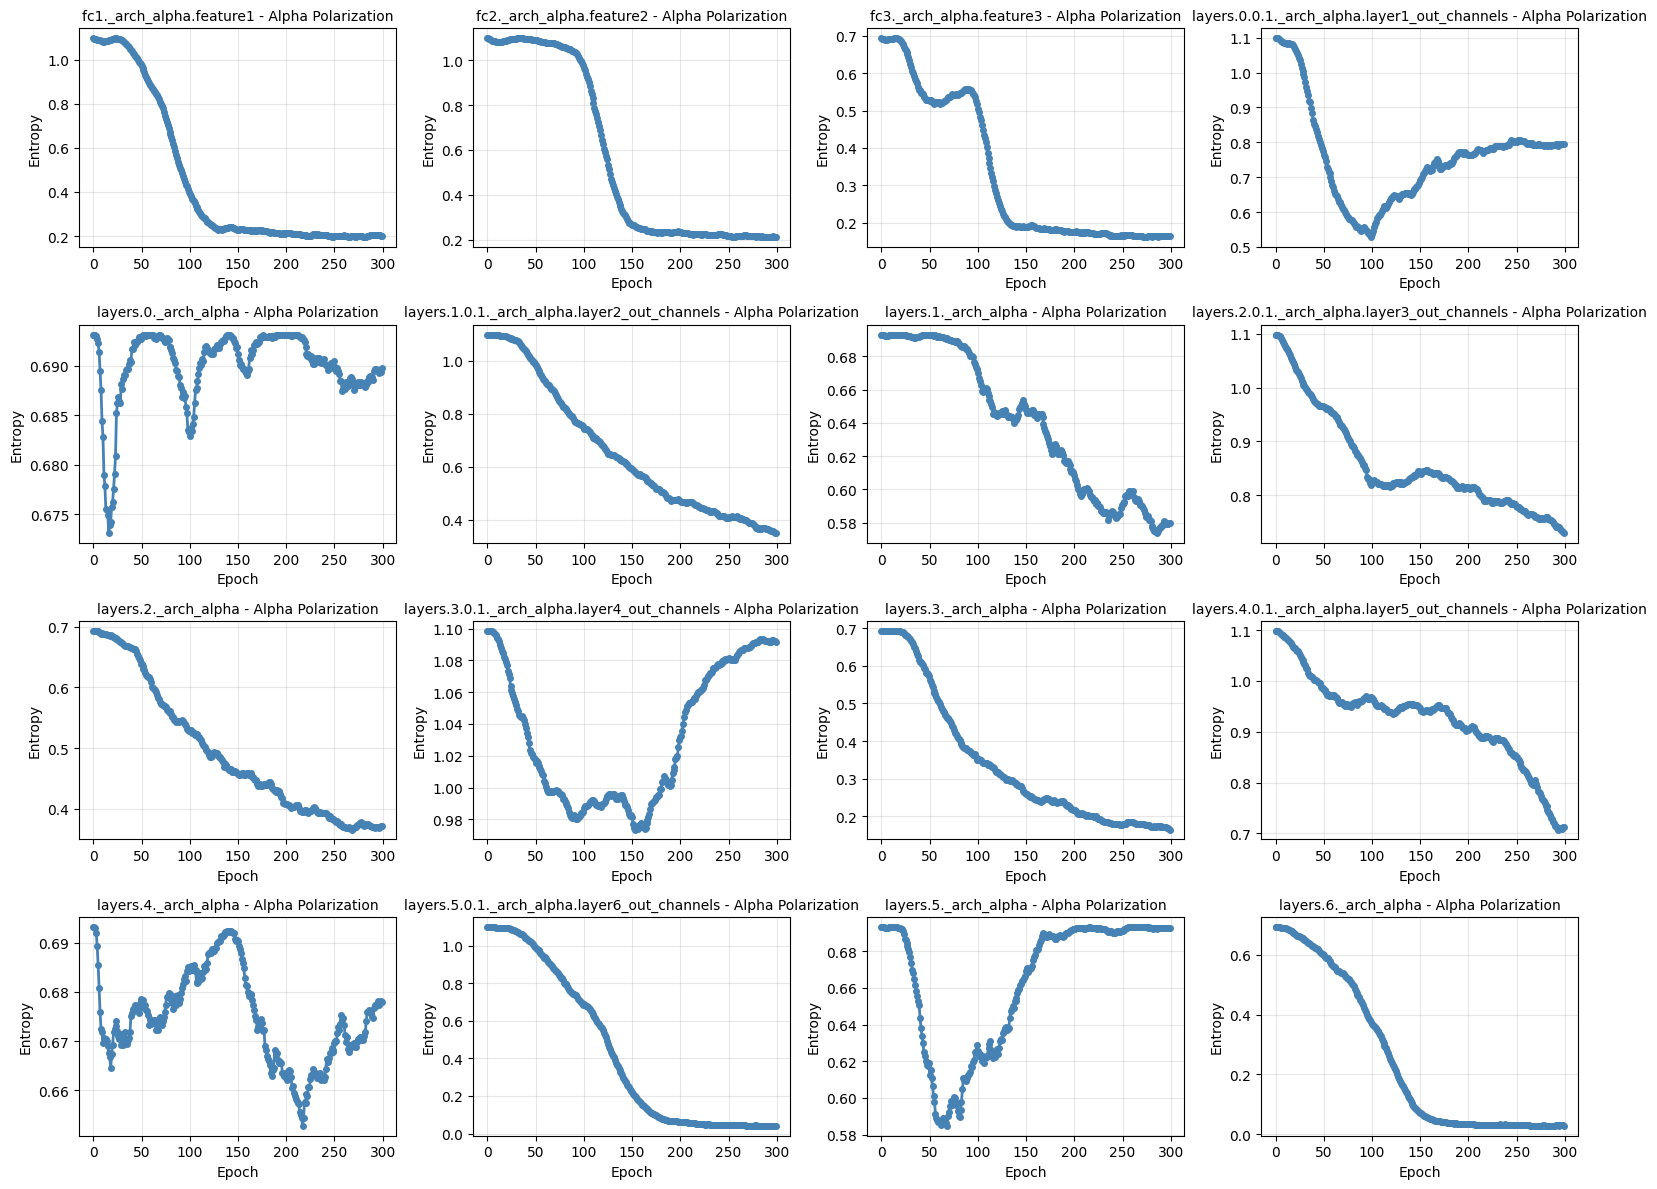


ALPHA POLARIZATION SUMMARY
fc1._arch_alpha.feature1 : entropy=0.1990, max_prob=0.9589, choice=0, Δentropy=0.8993
fc2._arch_alpha.feature2 : entropy=0.2123, max_prob=0.9554, choice=0, Δentropy=0.8861
fc3._arch_alpha.feature3 : entropy=0.1649, max_prob=0.9610, choice=0, Δentropy=0.5280
layers.0.0.1._arch_alpha.layer1_out_channels: entropy=0.7941, max_prob=0.7145, choice=0, Δentropy=0.3045
layers.0._arch_alpha     : entropy=0.6897, max_prob=0.5414, choice=0, Δentropy=0.0034
layers.1.0.1._arch_alpha.layer2_out_channels: entropy=0.3484, max_prob=0.9154, choice=1, Δentropy=0.7502
layers.1._arch_alpha     : entropy=0.5796, max_prob=0.7336, choice=0, Δentropy=0.1135
layers.2.0.1._arch_alpha.layer3_out_channels: entropy=0.7290, max_prob=0.7214, choice=1, Δentropy=0.3696
layers.2._arch_alpha     : entropy=0.3719, max_prob=0.8775, choice=1, Δentropy=0.3213
layers.3.0.1._arch_alpha.layer4_out_channels: entropy=1.0915, max_prob=0.3845, choice=2, Δentropy=0.0071
layers.3._arch_alpha     : entropy=0

In [530]:
# Load and visualize alpha evolution throughout the search
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import softmax

alpha_history_path = '/home/filippo/TESI_FILIPPO_LUCCHESI/alpha_history.pt'
if os.path.exists(alpha_history_path):
    history = torch.load(alpha_history_path, map_location='cpu')
    print(f"Loaded alpha history from {alpha_history_path}: {len(history)} epochs")
else:
    print(f"Warning: {alpha_history_path} not found. Run the search cell first.")
    history = None

if history is not None and len(history) > 0:
    # Get all alpha choice names from the first epoch
    alpha_names = sorted(list(history[0]['alphas'].keys()))
    num_alphas = len(alpha_names)
    print(f"Found {num_alphas} architectural choices")
    
    # Create figure with subplots for each alpha
    n_cols = 4
    n_rows = (num_alphas + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3*n_rows))
    if num_alphas == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    
    for idx, name in enumerate(alpha_names):
        ax = axes[idx]
        
        # Extract probabilities for this alpha over all epochs
        probs_list = []
        for epoch_data in history:
            alpha_tensor = epoch_data['alphas'][name]
            probs = softmax(alpha_tensor)
            probs_list.append(probs)
        
        probs_array = np.array(probs_list)  # shape: (num_epochs, num_choices)
        
        # Plot entropy over epochs
        entropy = -np.sum(probs_array * np.log(probs_array + 1e-12), axis=1)
        ax.plot(entropy, linewidth=2, color='steelblue', marker='o', markersize=4)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Entropy')
        ax.set_title(f'{name} - Alpha Polarization', fontsize=10)
        ax.grid(True, alpha=0.3)
    
    # Hide unused subplots
    for idx in range(num_alphas, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.savefig('/home/filippo/TESI_FILIPPO_LUCCHESI/alpha_evolution.png', dpi=150, bbox_inches='tight')
    print("Alpha evolution plot saved to /home/filippo/TESI_FILIPPO_LUCCHESI/alpha_evolution.png")
    plt.show()
    
    # Print summary statistics
    print("\n" + "="*60)
    print("ALPHA POLARIZATION SUMMARY")
    print("="*60)
    for idx, name in enumerate(alpha_names):
        probs_list = []
        for epoch_data in history:
            probs = softmax(epoch_data['alphas'][name])
            probs_list.append(probs)
        probs_array = np.array(probs_list)
        
        # Final entropy
        final_entropy = -np.sum(probs_array[-1] * np.log(probs_array[-1] + 1e-12))
        max_prob_final = np.max(probs_array[-1])
        winning_choice = np.argmax(probs_array[-1])
        
        # Entropy change
        initial_entropy = -np.sum(probs_array[0] * np.log(probs_array[0] + 1e-12))
        entropy_change = initial_entropy - final_entropy
        
        print(f"{name:25s}: entropy={final_entropy:.4f}, max_prob={max_prob_final:.4f}, choice={winning_choice}, Δentropy={entropy_change:.4f}")

Using last captured epoch from alpha_history: 299
Choices captured: 16

=== FINAL SUPERNET ALPHA STATE (LAST EPOCH) ===
Choice Name                                   Entropy    Max Prob   Winner 
--------------------------------------------------------------------------------
fc1.feature1                                  0.1990     0.9589     0      
fc2.feature2                                  0.2123     0.9554     0      
fc3.feature3                                  0.1649     0.9610     0      
layers.1.0.1.layer1_out_channels              0.7941     0.7145     0      
layers.1                                      0.6897     0.5414     0      
layers.2.0.1.layer2_out_channels              0.3484     0.9154     1      
layers.2                                      0.5796     0.7336     0      
layers.3.0.1.layer3_out_channels              0.7290     0.7214     1      
layers.3                                      0.3719     0.8775     1      
layers.4.0.1.layer4_out_channels       

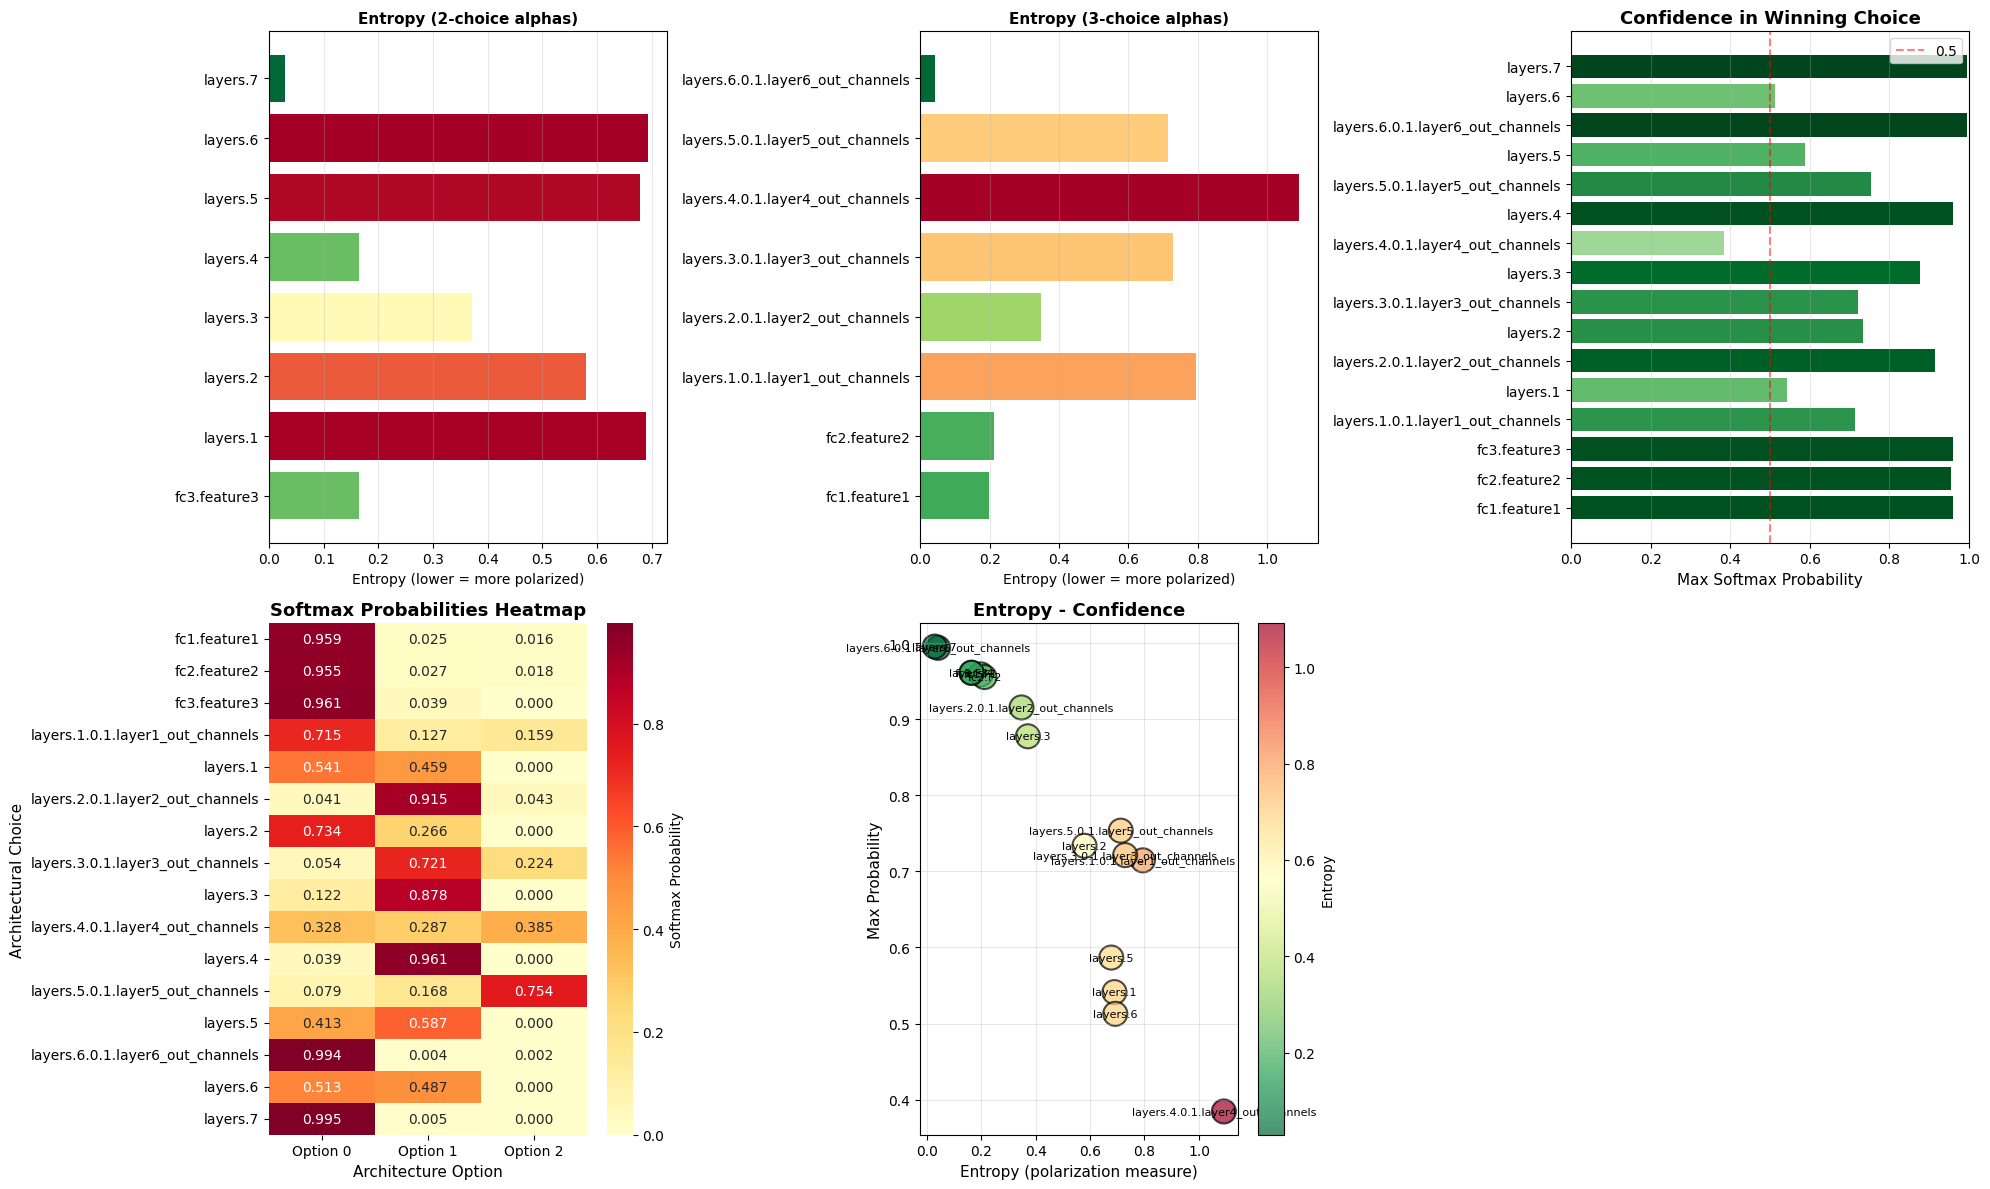

In [531]:
# Final supernet state from alpha_history (last captured epoch)
import re
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

alpha_history_path = '/home/filippo/TESI_FILIPPO_LUCCHESI/alpha_history.pt'
if not os.path.exists(alpha_history_path):
    raise FileNotFoundError(f'alpha_history.pt not found at {alpha_history_path}. Run the search cell first.')

history = torch.load(alpha_history_path, map_location='cpu')
if not history:
    raise RuntimeError('alpha_history is empty; no epochs were captured.')

last_epoch = history[-1]
last_epoch_idx = last_epoch.get('epoch', len(history) - 1)
alphas = last_epoch['alphas']
print(f'Using last captured epoch from alpha_history: {last_epoch_idx}')
print(f'Choices captured: {len(alphas)}')

def _clean_choice_name(name: str) -> str:
    cleaned = name.replace('._arch_alpha.', '.').replace('_arch_alpha', '')
    cleaned = cleaned.replace('..', '.')
    def _bump_layers(match):
        return f"layers.{int(match.group(1)) + 1}"
    cleaned = re.sub(r"\blayers\.(\d+)\b", _bump_layers, cleaned)
    return cleaned.strip('.')

alpha_summary = {}
for name in sorted(alphas.keys()):
    alpha_tensor = alphas[name].float().numpy()
    exp_vals = np.exp(alpha_tensor - np.max(alpha_tensor))
    probs = exp_vals / np.sum(exp_vals)
    alpha_summary[name] = {
        'raw': alpha_tensor,
        'probs': probs,
        'entropy': -np.sum(probs * np.log(probs + 1e-12)),
        'max_prob': np.max(probs),
        'winning_choice': np.argmax(probs),
        'num_instances': 1,
        'label': _clean_choice_name(name),
    }

print('\n=== FINAL SUPERNET ALPHA STATE (LAST EPOCH) ===')
print(f"{'Choice Name':<45} {'Entropy':<10} {'Max Prob':<10} {'Winner':<7}")
print('-' * 80)
for name in sorted(alpha_summary.keys()):
    data = alpha_summary[name]
    print(f"{data['label']:<45} {data['entropy']:<10.4f} {data['max_prob']:<10.4f} {int(data['winning_choice']):<7d}")

print('\nRaw probabilities per choice (last epoch):')
for name in sorted(alpha_summary.keys()):
    probs_str = np.array2string(alpha_summary[name]['probs'], precision=4, separator=', ')
    print(f"{alpha_summary[name]['label']}: {probs_str}")

def _plot_entropy_bars(ax, labels, entropies, title):
    if not entropies:
        ax.set_title(title, fontsize=11)
        ax.text(0.5, 0.5, 'No entries', ha='center', va='center')
        ax.axis('off')
        return
    ent_min, ent_max = min(entropies), max(entropies)
    normed = (np.array(entropies) - ent_min) / max(ent_max - ent_min, 1e-12)
    colors = plt.cm.RdYlGn(1.0 - normed)
    ax.barh(labels, entropies, color=colors)
    ax.set_xlabel('Entropy (lower = more polarized)', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='x')

# Create visualizations (same style as Cell 21)
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# Split by number of choices
two_choice_labels = []
two_choice_entropies = []
three_choice_labels = []
three_choice_entropies = []
for name in sorted(alpha_summary.keys()):
    label = alpha_summary[name]['label']
    entropy = alpha_summary[name]['entropy']
    num_choices = len(alpha_summary[name]['probs'])
    if num_choices == 2:
        two_choice_labels.append(label)
        two_choice_entropies.append(entropy)
    elif num_choices == 3:
        three_choice_labels.append(label)
        three_choice_entropies.append(entropy)

# 1. Entropy across 2-choice alphas
_plot_entropy_bars(axes[0, 0], two_choice_labels, two_choice_entropies, 'Entropy (2-choice alphas)')

# 2. Entropy across 3-choice alphas
_plot_entropy_bars(axes[0, 1], three_choice_labels, three_choice_entropies, 'Entropy (3-choice alphas)')

# 3. Max probability (winning choice confidence)
ax = axes[0, 2]
choice_names_sorted = [alpha_summary[name]['label'] for name in sorted(alpha_summary.keys())]
max_probs = [alpha_summary[name]['max_prob'] for name in sorted(alpha_summary.keys())]
colors_prob = plt.cm.Greens(np.array(max_probs))
ax.barh(choice_names_sorted, max_probs, color=colors_prob)
ax.set_xlabel('Max Softmax Probability', fontsize=11)
ax.set_title('Confidence in Winning Choice', fontsize=13, fontweight='bold')
ax.set_xlim([0, 1])
ax.axvline(0.5, color='red', linestyle='--', alpha=0.5, label='0.5')
ax.legend()
ax.grid(True, alpha=0.3, axis='x')

# 4. Heatmap of softmax probabilities for each choice
ax = axes[1, 0]
heatmap_data = []
max_num_options = 0
for name in sorted(alpha_summary.keys()):
    probs = alpha_summary[name]['probs']
    heatmap_data.append(probs)
    max_num_options = max(max_num_options, len(probs))

heatmap_array = np.zeros((len(choice_names_sorted), max_num_options))
for i, probs in enumerate(heatmap_data):
    heatmap_array[i, :len(probs)] = probs

sns.heatmap(
    heatmap_array, annot=True, fmt='.3f', cmap='YlOrRd',
    yticklabels=choice_names_sorted, xticklabels=[f'Option {i}' for i in range(max_num_options)],
    ax=ax, cbar_kws={'label': 'Softmax Probability'}
 )
ax.set_title('Softmax Probabilities Heatmap', fontsize=13, fontweight='bold')
ax.set_xlabel('Architecture Option', fontsize=11)
ax.set_ylabel('Architectural Choice', fontsize=11)

# 5. Scatter plot: Entropy vs Max Probability
ax = axes[1, 1]
entropies_sorted = [alpha_summary[name]['entropy'] for name in sorted(alpha_summary.keys())]
scatter = ax.scatter(
    entropies_sorted, max_probs, s=300, c=entropies_sorted,
    cmap='RdYlGn_r', alpha=0.7, edgecolors='black', linewidth=1.5
 )
for i, name in enumerate(choice_names_sorted):
    ax.annotate(
        name.replace('layer_', 'L').replace('feature', 'F'),
        (entropies_sorted[i], max_probs[i]),
        fontsize=8, ha='center', va='center'
    )
ax.set_xlabel('Entropy (polarization measure)', fontsize=11)
ax.set_ylabel('Max Probability', fontsize=11)
ax.set_title('Entropy - Confidence', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Entropy', fontsize=10)

# Hide unused subplot
axes[1, 2].axis('off')

plt.tight_layout()
plt.savefig('alpha_polarization_final_state.png', dpi=150, bbox_inches='tight')
print("\n✓ Visualization saved to: alpha_polarization_final_state.png")
plt.show()


=== FINAL ALPHA POLARIZATION SUMMARY ===

Choice Name                    Entropy      Max Prob     Winner       # Instances
--------------------------------------------------------------------------------
feature1                       0.2042       0.9577       0            2
feature2                       0.3574       0.9122       0            2
feature3                       0.1823       0.9554       0            2
layer1_out_channels            0.8511       0.6167       1            6
layer2_out_channels            0.8307       0.6784       0            6
layer3_out_channels            0.6760       0.7769       2            6
layer4_out_channels            0.5275       0.8471       2            6
layer5_out_channels            0.9189       0.6057       0            6
layer6_out_channels            0.0752       0.9874       0            6
layer_1                        0.6421       0.6584       1            1
layer_2                        0.1775       0.9570       1            1
lay

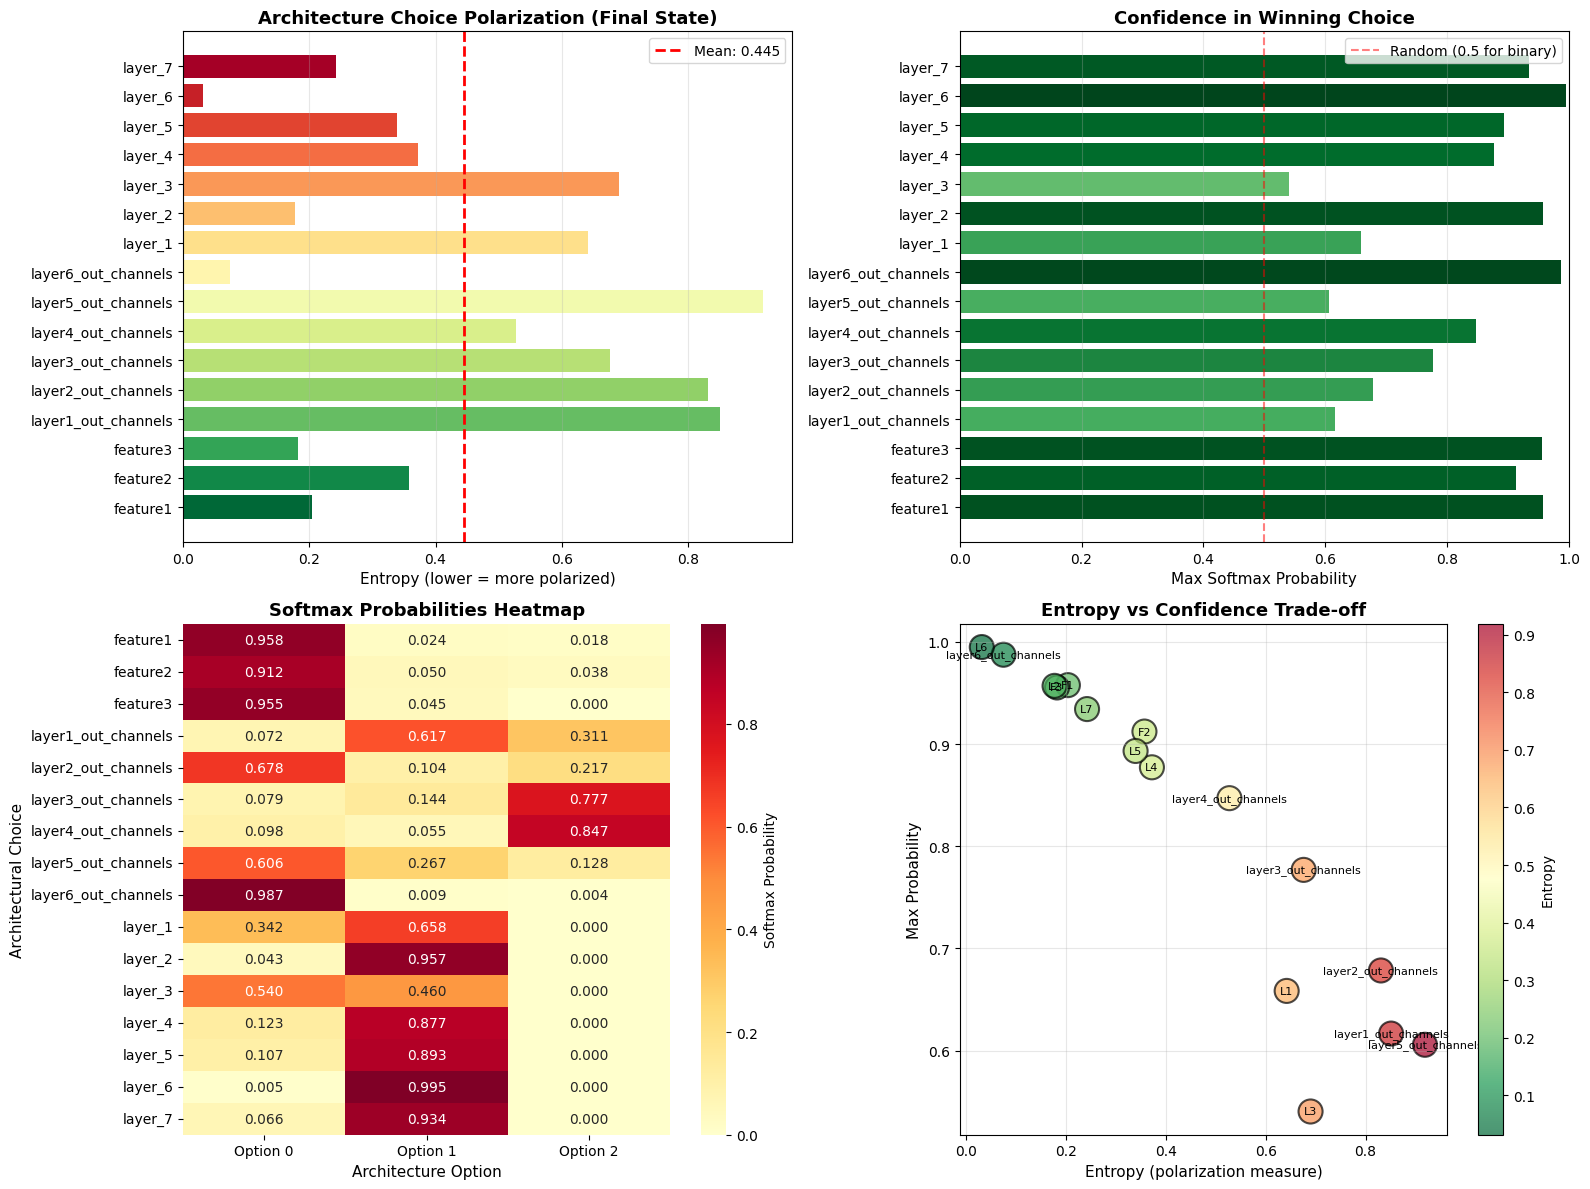

In [392]:
# Extract and visualize final alpha states from checkpoint
import subprocess
import sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "matplotlib", "seaborn"])

import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

checkpoint_path = './checkpoints/best-checkpoint-v33.ckpt'
ckpt = torch.load(checkpoint_path, map_location='cpu')
sd = ckpt.get('state_dict', {})

# Extract all arch_alpha tensors
alpha_data = {}
for key, value in sd.items():
    if '_arch_alpha' in key:
        # Extract choice name
        if '._arch_alpha.' in key:
            choice_name = key.split('._arch_alpha.')[1]
        else:
            # Parse from path like training_module._model.layers.0._arch_alpha
            parts = key.split('.')
            if 'layers' in key:
                layer_idx = int([p for p in parts if p.isdigit()][0])
                choice_name = f'layer_{layer_idx + 1}'
            else:
                choice_name = key.split('._arch_alpha')[-1] or 'unknown'
        
        if choice_name not in alpha_data:
            alpha_data[choice_name] = []
        
        alpha_tensor = value.cpu().numpy()
        probs = np.exp(alpha_tensor) / np.sum(np.exp(alpha_tensor))  # softmax
        alpha_data[choice_name].append({
            'raw': alpha_tensor,
            'probs': probs,
            'entropy': -np.sum(probs * np.log(probs + 1e-10)),
            'max_prob': np.max(probs),
            'winning_choice': np.argmax(probs)
        })

# Aggregate by averaging duplicates (multiple paths in supernet)
alpha_summary = {}
for choice_name, data_list in alpha_data.items():
    avg_raw = np.mean([d['raw'] for d in data_list], axis=0)
    avg_probs = np.exp(avg_raw) / np.sum(np.exp(avg_raw))
    alpha_summary[choice_name] = {
        'raw': avg_raw,
        'probs': avg_probs,
        'entropy': -np.sum(avg_probs * np.log(avg_probs + 1e-10)),
        'max_prob': np.max(avg_probs),
        'winning_choice': np.argmax(avg_probs),
        'num_instances': len(data_list)
    }

print("=== FINAL ALPHA POLARIZATION SUMMARY ===\n")
print(f"{'Choice Name':<30} {'Entropy':<12} {'Max Prob':<12} {'Winner':<12} {'# Instances'}")
print("-" * 80)

entropies = []
for choice_name in sorted(alpha_summary.keys()):
    data = alpha_summary[choice_name]
    entropies.append(data['entropy'])
    winner_idx = data['winning_choice']
    print(f"{choice_name:<30} {data['entropy']:<12.4f} {data['max_prob']:<12.4f} {winner_idx:<12d} {data['num_instances']}")

print(f"\nMean entropy across all choices: {np.mean(entropies):.4f}")
print(f"Min entropy (most polarized): {np.min(entropies):.4f}")
print(f"Max entropy (least polarized): {np.max(entropies):.4f}")

# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Entropy across all choices
ax = axes[0, 0]
choice_names_sorted = sorted(alpha_summary.keys())
entropies_sorted = [alpha_summary[name]['entropy'] for name in choice_names_sorted]
colors = plt.cm.RdYlGn_r(np.linspace(0, 1, len(entropies_sorted)))
ax.barh(choice_names_sorted, entropies_sorted, color=colors)
ax.set_xlabel('Entropy (lower = more polarized)', fontsize=11)
ax.set_title('Architecture Choice Polarization (Final State)', fontsize=13, fontweight='bold')
ax.axvline(np.mean(entropies_sorted), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(entropies_sorted):.3f}')
ax.legend()
ax.grid(True, alpha=0.3, axis='x')

# 2. Max probability (winning choice confidence)
ax = axes[0, 1]
max_probs = [alpha_summary[name]['max_prob'] for name in choice_names_sorted]
colors_prob = plt.cm.Greens(np.array(max_probs))
ax.barh(choice_names_sorted, max_probs, color=colors_prob)
ax.set_xlabel('Max Softmax Probability', fontsize=11)
ax.set_title('Confidence in Winning Choice', fontsize=13, fontweight='bold')
ax.set_xlim([0, 1])
ax.axvline(0.5, color='red', linestyle='--', alpha=0.5, label='Random (0.5 for binary)')
ax.legend()
ax.grid(True, alpha=0.3, axis='x')

# 3. Heatmap of softmax probabilities for each choice
ax = axes[1, 0]
# Prepare data for heatmap
heatmap_data = []
max_num_options = 0
for name in choice_names_sorted:
    probs = alpha_summary[name]['probs']
    heatmap_data.append(probs)
    max_num_options = max(max_num_options, len(probs))

# Pad to same length
heatmap_array = np.zeros((len(choice_names_sorted), max_num_options))
for i, probs in enumerate(heatmap_data):
    heatmap_array[i, :len(probs)] = probs

import seaborn as sns
sns.heatmap(heatmap_array, annot=True, fmt='.3f', cmap='YlOrRd', 
            yticklabels=choice_names_sorted, xticklabels=[f'Option {i}' for i in range(max_num_options)],
            ax=ax, cbar_kws={'label': 'Softmax Probability'})
ax.set_title('Softmax Probabilities Heatmap', fontsize=13, fontweight='bold')
ax.set_xlabel('Architecture Option', fontsize=11)
ax.set_ylabel('Architectural Choice', fontsize=11)

# 4. Scatter plot: Entropy vs Max Probability
ax = axes[1, 1]
scatter = ax.scatter(entropies_sorted, max_probs, s=300, c=entropies_sorted, 
                     cmap='RdYlGn_r', alpha=0.7, edgecolors='black', linewidth=1.5)
for i, name in enumerate(choice_names_sorted):
    ax.annotate(name.replace('layer_', 'L').replace('feature', 'F'), 
                (entropies_sorted[i], max_probs[i]), 
                fontsize=8, ha='center', va='center')
ax.set_xlabel('Entropy (polarization measure)', fontsize=11)
ax.set_ylabel('Max Probability', fontsize=11)
ax.set_title('Entropy vs Confidence Trade-off', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Entropy', fontsize=10)

plt.tight_layout()
plt.savefig('alpha_polarization_final_state.png', dpi=150, bbox_inches='tight')
print("\n✓ Visualization saved to: alpha_polarization_final_state.png")
plt.show()


# Results and Best Architecture

In [532]:
# Export best architecture
best_arch = experiment_results.export_top_models(formatter='instance', top_k=1)[0]
best_arch_desc = experiment_results.export_top_models(formatter='dict', top_k=1)[0]
best_arch_state_dict = best_arch.state_dict()

print("Best Architecture Description:")
print(best_arch_desc)

Best Architecture Description:
{'layer_1': 0, 'layer1_out_channels': 16, 'layer_2': 0, 'layer2_out_channels': 32, 'layer_3': 1, 'layer3_out_channels': 32, 'layer_4': 1, 'layer4_out_channels': 64, 'layer_5': 1, 'layer5_out_channels': 64, 'layer_6': 0, 'layer6_out_channels': 16, 'layer_7': 0, 'feature1': 32, 'feature2': 32, 'feature3': 32}


In [264]:
# Experiment configuration
print("Experiment Configuration:")
print(experiment_results.config)

Experiment Configuration:
NasExperimentConfig(experiment_name='PhotonicDARTS_Quant-v1', experiment_type='nas', search_space_file=None, search_space='_reserved_', trial_command='', trial_code_directory='.', trial_concurrency=1, trial_gpu_number=None, max_experiment_duration=None, max_trial_number=None, max_trial_duration=None, nni_manager_ip=None, use_annotation=False, debug=False, log_level=None, experiment_working_directory='./DartsCheckpoints_Quant', tuner_gpu_indices=None, tuner=_AlgorithmConfig(name='_none_', class_name=None, code_directory=None, class_args={}), assessor=_AlgorithmConfig(name='_none_', class_name=None, code_directory=None, class_args={}), advisor=_AlgorithmConfig(name='_none_', class_name=None, code_directory=None, class_args={}), training_service=LocalConfig(platform='local', trial_command=<dataclasses._MISSING_TYPE object at 0x7fee8e953ed0>, trial_code_directory=<dataclasses._MISSING_TYPE object at 0x7fee8e953ed0>, trial_gpu_number=<dataclasses._MISSING_TYPE obje

# Auto arch code generator

### Load Checkpoint

In [363]:
checkpoint_path = './checkpoints/best-checkpoint-v31.ckpt'

checkpoint = torch.load(checkpoint_path, map_location=torch.device('cpu'))

checkpoint_model = CustomDARTSSpace(input_channels=3, channels=64, num_classes=10, layers=7, verbose=0, num_bits=4)

checkpoint_state_dict = checkpoint_model.state_dict()
pretrained_state_dict = checkpoint['state_dict']

if 'global_step' in checkpoint:
    print('Global Step:', checkpoint['global_step'])

if 'callbacks' in checkpoint and isinstance(checkpoint['callbacks'], dict):
    for key, callback in checkpoint['callbacks'].items():
        if isinstance(callback, dict) and 'best_model_score' in callback:
            print('Best Model Score (Train Accuracy):', callback['best_model_score'].item())

Global Step: 64906
Best Model Score (Train Accuracy): 0.8500000238418579


In [ ]:
# # Inspect checkpoint contents relevant to supernet vs frozen export
# from collections import Counter

# checkpoint_path = './checkpoints/best-checkpoint.ckpt'
# ckpt = torch.load(checkpoint_path, map_location='cpu')
# sd = ckpt.get('state_dict', {})

# print('Checkpoint top-level keys:', list(ckpt.keys()))
# print('State dict tensor count:', len(sd))

# # Show the first several parameter names so we can see what is actually stored.
# for key in list(sd.keys())[:60]:
#     value = sd[key]
#     shape = tuple(value.shape) if hasattr(value, 'shape') else type(value)
#     print(key, shape)

# # Count the kinds of tensors that appear in the checkpoint.
# category_counts = Counter()
# for key in sd:
#     if 'arch_alpha' in key:
#         category_counts['arch_alpha'] += 1
#     elif 'bn' in key or 'batchnorm' in key.lower():
#         category_counts['batchnorm'] += 1
#     elif '.weight' in key or '.bias' in key:
#         category_counts['weights_or_biases'] += 1
#     else:
#         category_counts['other'] += 1

# print('\nTensor category counts:', dict(category_counts))


Checkpoint top-level keys: ['epoch', 'global_step', 'pytorch-lightning_version', 'state_dict', 'loops', 'callbacks', 'optimizer_states', 'lr_schedulers']
State dict tensor count: 147
training_module._model.layers.0._arch_alpha (2,)
training_module._model.layers.0.0.1.weight (64, 16, 3, 3)
training_module._model.layers.0.0.1._arch_alpha.layer1_out_channels (3,)
training_module._model.layers.0.0.2.weight (64,)
training_module._model.layers.0.0.2.bias (64,)
training_module._model.layers.0.0.2.running_mean (64,)
training_module._model.layers.0.0.2.running_var (64,)
training_module._model.layers.0.0.2.num_batches_tracked ()
training_module._model.layers.0.0.2._arch_alpha.layer1_out_channels (3,)
training_module._model.layers.0.1.0.weight (64, 16, 3, 3)
training_module._model.layers.0.1.0._arch_alpha.layer1_out_channels (3,)
training_module._model.layers.0.1.2.weight (64,)
training_module._model.layers.0.1.2.bias (64,)
training_module._model.layers.0.1.2.running_mean (64,)
training_module._m

In [405]:
best_arch_desc

{'layer_1': 1,
 'layer1_out_channels': 32,
 'layer_2': 1,
 'layer2_out_channels': 16,
 'layer_3': 0,
 'layer3_out_channels': 64,
 'layer_4': 1,
 'layer4_out_channels': 64,
 'layer_5': 1,
 'layer5_out_channels': 16,
 'layer_6': 1,
 'layer6_out_channels': 16,
 'layer_7': 1,
 'feature1': 32,
 'feature2': 32,
 'feature3': 32}

# From-Scratch Model

In [3]:
import json
import os

arch_path = 'best_arch_darts_v90.json'
if not os.path.exists(arch_path):
    raise FileNotFoundError(f'{arch_path} not found. Make sure it exists in the working directory.')

with open(arch_path, 'r') as f:
    arch_dict = json.load(f)

print('Loaded arch_dict keys:', sorted(arch_dict.keys()))

Loaded arch_dict keys: ['feature1', 'feature2', 'feature3', 'layer1_out_channels', 'layer2_out_channels', 'layer3_out_channels', 'layer4_out_channels', 'layer5_out_channels', 'layer6_out_channels', 'layer_1', 'layer_2', 'layer_3', 'layer_4', 'layer_5', 'layer_6', 'layer_7']


In [68]:
max_epochs = 500
num_bits = 6

from DoReFaLayers import FrozenDoReFaConv2d, FrozenDoReFaLinear, dorefa_activation
class PhotonicArchQuant(torch.nn.Module):  #quickg
    def __init__(self, drop_path_prob=0.0, arch_dict=None, num_bits=6, max_epochs=200):
        super().__init__()
        if arch_dict is None:
            raise ValueError("arch_dict is required to build PhotonicArchQuant")
        self.arch_dict = arch_dict
        self.drop_path_prob = drop_path_prob
        self.num_bits = num_bits
        self.max_epochs = max_epochs

        self.preliminary_layer = FrozenDoReFaConv2d(3, 16, kernel_size=3, padding=0, bias=False, num_bits=num_bits)
        self.layer0_bn = torch.nn.BatchNorm2d(16)
        self.layer0_relu = torch.nn.ReLU(inplace=False)

        layer_out_channels = [
            arch_dict['layer1_out_channels'],
            arch_dict['layer2_out_channels'],
            arch_dict['layer3_out_channels'],
            arch_dict['layer4_out_channels'],
            arch_dict['layer5_out_channels'],
            arch_dict['layer6_out_channels'],
            22,
        ]

        self.layers = torch.nn.ModuleList()
        in_channels = 16
        for layer_index, out_channels in enumerate(layer_out_channels, start=1):
            if arch_dict[f'layer_{layer_index}'] == 0:
                block = torch.nn.Sequential(
                    torch.nn.AvgPool2d(kernel_size=2, stride=1, padding=1),
                    FrozenDoReFaConv2d(in_channels, out_channels, kernel_size=3, bias=False, num_bits=num_bits),
                    torch.nn.BatchNorm2d(out_channels),
                    torch.nn.ReLU(inplace=False),
                )
            else:
                block = torch.nn.Sequential(
                    FrozenDoReFaConv2d(in_channels, out_channels, kernel_size=3, bias=False, num_bits=num_bits),
                    torch.nn.AvgPool2d(kernel_size=2, stride=1, padding=1),
                    torch.nn.BatchNorm2d(out_channels),
                    torch.nn.ReLU(inplace=False),
                )
            self.layers.append(block)
            in_channels = out_channels

        self.pool = torch.nn.AdaptiveAvgPool2d((3, 3))
        self.fc1 = FrozenDoReFaLinear(198, arch_dict['feature1'], num_bits=num_bits)
        self.fc2 = FrozenDoReFaLinear(arch_dict['feature1'], arch_dict['feature2'], num_bits=num_bits)
        self.fc3 = FrozenDoReFaLinear(arch_dict['feature2'], arch_dict['feature3'], num_bits=num_bits)
        self.relu = torch.nn.ReLU(inplace=False)
        self.classifier = FrozenDoReFaLinear(arch_dict['feature3'], 10, num_bits=num_bits)

    def _forward_core(self, x, act_quant_bits, w_quant_bits, pre_act_bits=None, post_act_bits=None):
        if pre_act_bits is not None:
            x = dorefa_activation(x, pre_act_bits)
        x = self.preliminary_layer(x, w_quant_bits)
        x = self.layer0_bn(x)
        x = self.layer0_relu(x)

        for i, block in enumerate(self.layers):
            x = dorefa_activation(x, act_quant_bits)
            for sublayer in block:

                if isinstance(sublayer, (FrozenDoReFaConv2d, FrozenDoReFaLinear)):
                    x = sublayer(x, w_quant_bits)
                else:
                    x = sublayer(x)
            if i in (1, 3, 6):
                x = torch.nn.AvgPool2d(kernel_size=2, stride=2)(x)

        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = dorefa_activation(x, act_quant_bits)
        x = self.fc1(x)
        x = self.relu(x)
        x = dorefa_activation(x, act_quant_bits)
        x = self.fc2(x)
        x = self.relu(x)
        x = dorefa_activation(x, act_quant_bits)
        x = self.fc3(x)
        x = self.relu(x)
        if post_act_bits is not None:
            x = dorefa_activation(x, post_act_bits)
        x = self.classifier(x)
        return x

    def forward_train(self, x, epoch: int = 0):
        act_quant_bits = 8 if epoch < self.max_epochs // 3 else self.num_bits
        w_quant_bits = 8 if epoch < self.max_epochs // 3 else self.num_bits
        pre_act_bits = None
        post_act_bits = None
        if epoch > self.max_epochs // 3 and epoch < 2 * self.max_epochs // 3:
            pre_act_bits = 8
            post_act_bits = 8
        elif epoch >= 2 * self.max_epochs // 3:
            pre_act_bits = 6
            post_act_bits = 6
        return self._forward_core(x, act_quant_bits, w_quant_bits, pre_act_bits, post_act_bits)

    def forward_infer(self, x, num_bits: int | None = None):
        if num_bits is None:
            num_bits = self.num_bits
        return self._forward_core(x, num_bits, num_bits, pre_act_bits=num_bits, post_act_bits=num_bits)

    def forward(self, x, epoch: int | None = None, inference: bool = False):
        if epoch is None or epoch == 0:
            epoch = getattr(self, 'epoch', epoch)
        self.epoch = 0 if epoch is None else epoch
        if inference or not self.training:
            return self.forward_infer(x)
        return self.forward_train(x, self.epoch)

    def set_drop_path_prob(self, drop_path_prob):
        self.drop_path_prob = drop_path_prob

In [69]:
scratch_model = PhotonicArchQuant(arch_dict=arch_dict, num_bits=num_bits, max_epochs=max_epochs)
scratch_model

PhotonicArchQuant(
  (preliminary_layer): FrozenDoReFaConv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), bias=False)
  (layer0_bn): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layer0_relu): ReLU()
  (layers): ModuleList(
    (0): Sequential(
      (0): AvgPool2d(kernel_size=2, stride=1, padding=1)
      (1): FrozenDoReFaConv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), bias=False)
      (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (3): ReLU()
    )
    (1): Sequential(
      (0): AvgPool2d(kernel_size=2, stride=1, padding=1)
      (1): FrozenDoReFaConv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
      (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (3): ReLU()
    )
    (2): Sequential(
      (0): FrozenDoReFaConv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
      (1): AvgPool2d(kernel_size=2, stride=1, padding=1)
      (2): BatchNorm2d(

In [64]:
import json

# Export the best architecture description to JSON for use in other scripts
arch_export_path = 'best_arch_darts_v90.json'
with open(arch_export_path, 'w') as f:
    json.dump(best_arch_desc, f, indent=2)
print(f"Architecture exported to {arch_export_path}")
print("Architecture choices:", best_arch_desc)

Architecture exported to best_arch_darts_v90.json
Architecture choices: {'layer_1': 0, 'layer1_out_channels': 16, 'layer_2': 0, 'layer2_out_channels': 32, 'layer_3': 1, 'layer3_out_channels': 32, 'layer_4': 1, 'layer4_out_channels': 64, 'layer_5': 1, 'layer5_out_channels': 64, 'layer_6': 0, 'layer6_out_channels': 16, 'layer_7': 0, 'feature1': 32, 'feature2': 32, 'feature3': 32}


In [ ]:
# # Use the DoReFa-frozen variant for all downstream training/evaluation cells.
# scratch_model = scratch_model_frozen_dorefa
# print(type(scratch_model).__name__)

CustomDARTSSpace


### Rename dictionary keys

In [77]:
best_arch_state_dict = scratch_model.state_dict()

## Load weights

In [284]:
scratch_model.load_state_dict(best_arch_state_dict)

<All keys matched successfully>

In [70]:
def evaluate_model(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total_samples = 0

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

    avg_loss = total_loss / len(dataloader)
    accuracy = correct / total_samples
    return avg_loss, accuracy

In [71]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

scratch_model.to(device)
scratch_model.train()
module = DartsClassificationModule(2e-2, 0., 0., max_epochs)
module.set_model(scratch_model)
trainer = Trainer(max_epochs=module.max_epochs, accelerator="auto", gradient_clip_val=1.0)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [72]:
# Get the current Jupyter kernel process
p = psutil.Process(os.getpid())

# Set the niceness to 19 (Lowest CPU priority)
p.nice(19)
trainer.fit(module, train_loader)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type              | Params | Mode  | FLOPs
----------------------------------------------------------------
0 | criterion | CrossEntropyLoss  | 0      | train | 0    
1 | metrics   | ModuleDict        | 0      | train | 0    
2 | _model    | PhotonicArchQuant | 93.6 K | train | 0    
----------------------------------------------------------------
93.6 K    Trainable params
0         Non-trainable params
93.6 K    Total params
0.374     Total estimated model params size (MB)
49        Modules in train mode
0         Modules in eval mode
0         Total Flops


Weight params: 32
Arch params (excluded): 0
Training: |                                                                                                                               | 0/? [00:00<?, ?it/s]
=== Attached alpha gradient hooks ===

Epoch 499: 100%|████████████████████████████████████████████████████████████████| 391/391 [00:10<00:00, 38.34it/s, v_num=106, train_loss=0.590, train_acc=0.837]

`Trainer.fit` stopped: `max_epochs=500` reached.


Epoch 499: 100%|████████████████████████████████████████████████████████████████| 391/391 [00:10<00:00, 38.29it/s, v_num=106, train_loss=0.590, train_acc=0.837]


In [76]:
criterion = nn.CrossEntropyLoss()
scratch_model.to(device)

valid_loader = DataLoader(
    test_data, batch_size=batch_size,
    pin_memory=True, num_workers=0, persistent_workers=False
)

avg_loss, accuracy = evaluate_model(scratch_model, valid_loader, criterion, device)
print(f'Validation Loss: {avg_loss:.4f}, Accuracy: {accuracy:.4%}')

Validation Loss: 0.4707, Accuracy: 84.5700%


In [59]:
max_epochs = 500
num_bits = 6

from DoReFaLayers import FrozenDoReFaConv2d, FrozenDoReFaLinear, dorefa_activation
class PhotonicArchQuant2(torch.nn.Module):  #quickg
    def __init__(self, drop_path_prob=0.0, arch_dict=None, num_bits=6, max_epochs=200):
        super().__init__()
        if arch_dict is None:
            raise ValueError("arch_dict is required to build PhotonicArchQuant")
        self.arch_dict = arch_dict
        self.drop_path_prob = drop_path_prob
        self.num_bits = num_bits
        self.max_epochs = max_epochs

        self.preliminary_layer = FrozenDoReFaConv2d(3, 16, kernel_size=3, padding=0, bias=False, num_bits=num_bits)
        self.layer0_bn = torch.nn.BatchNorm2d(16)
        self.layer0_relu = torch.nn.ReLU(inplace=False)

        layer_out_channels = [
            arch_dict['layer1_out_channels'],
            arch_dict['layer2_out_channels'],
            arch_dict['layer3_out_channels'],
            arch_dict['layer4_out_channels'],
            arch_dict['layer5_out_channels'],
            arch_dict['layer6_out_channels'],
            22,
        ]

        self.layers = torch.nn.ModuleList()
        in_channels = 16
        for layer_index, out_channels in enumerate(layer_out_channels, start=1):
            if arch_dict[f'layer_{layer_index}'] == 0:
                block = torch.nn.Sequential(
                    torch.nn.AvgPool2d(kernel_size=2, stride=1, padding=1),
                    FrozenDoReFaConv2d(in_channels, out_channels, kernel_size=3, bias=False, num_bits=num_bits),
                    torch.nn.BatchNorm2d(out_channels),
                    torch.nn.ReLU(inplace=False),
                )
            else:
                block = torch.nn.Sequential(
                    FrozenDoReFaConv2d(in_channels, out_channels, kernel_size=3, bias=False, num_bits=num_bits),
                    torch.nn.AvgPool2d(kernel_size=2, stride=1, padding=1),
                    torch.nn.BatchNorm2d(out_channels),
                    torch.nn.ReLU(inplace=False),
                )
            self.layers.append(block)
            in_channels = out_channels

        self.pool = torch.nn.AdaptiveAvgPool2d((3, 3))
        self.fc1 = FrozenDoReFaLinear(198, arch_dict['feature1'], num_bits=num_bits)
        self.fc2 = FrozenDoReFaLinear(arch_dict['feature1'], arch_dict['feature2'], num_bits=num_bits)
        self.fc3 = FrozenDoReFaLinear(arch_dict['feature2'], arch_dict['feature3'], num_bits=num_bits)
        self.relu = torch.nn.ReLU(inplace=False)
        self.classifier = FrozenDoReFaLinear(arch_dict['feature3'], 10, num_bits=num_bits)

    def _forward_core(self, x, act_quant_bits, w_quant_bits, pre_act_bits=None, post_act_bits=None):
        if pre_act_bits is not None:
            x = dorefa_activation(x, pre_act_bits)
        x = self.preliminary_layer(x, w_quant_bits)
        x = self.layer0_bn(x)
        x = self.layer0_relu(x)

        for i, block in enumerate(self.layers):
            x = dorefa_activation(x, act_quant_bits)
            for sublayer in block:

                if isinstance(sublayer, (FrozenDoReFaConv2d, FrozenDoReFaLinear)):
                    x = sublayer(x, w_quant_bits)
                else:
                    x = sublayer(x)
            if i in (1, 3, 6):
                x = torch.nn.AvgPool2d(kernel_size=2, stride=2)(x)

        x = self.pool(x)
        x = torch.flatten(x, 1)
        x = dorefa_activation(x, act_quant_bits)
        x = self.fc1(x)
        x = self.relu(x)
        x = dorefa_activation(x, act_quant_bits)
        x = self.fc2(x)
        x = self.relu(x)
        x = dorefa_activation(x, act_quant_bits)
        x = self.fc3(x)
        x = self.relu(x)
        if post_act_bits is not None:
            x = dorefa_activation(x, post_act_bits)
        x = self.classifier(x)
        return x

    def forward_train(self, x, epoch: int = 0):
        act_quant_bits = 8 if epoch < self.max_epochs // 3 else self.num_bits
        w_quant_bits = 8 if epoch < self.max_epochs // 3 else self.num_bits
        pre_act_bits = None
        post_act_bits = None
        if epoch > self.max_epochs // 3 and epoch < 2 * self.max_epochs // 3:
            pre_act_bits = 8
            post_act_bits = 8
        elif epoch >= 2 * self.max_epochs // 3:
            pre_act_bits = 6
            post_act_bits = 6
        return self._forward_core(x, act_quant_bits, w_quant_bits, pre_act_bits, post_act_bits)

    def forward_infer(self, x, num_bits: int | None = None):
        if num_bits is None:
            num_bits = self.num_bits
        return self._forward_core(x, num_bits, num_bits, pre_act_bits=num_bits, post_act_bits=num_bits)

    def forward(self, x, epoch: int | None = None, inference: bool = False):
        if epoch is None or epoch == 0:
            epoch = getattr(self, 'epoch', epoch)
        self.epoch = 0 if epoch is None else epoch
        print("epoch in forward:", self.epoch)
        if inference or not self.training:
            return self.forward_infer(x)
        return self.forward_train(x, self.epoch)

    def set_drop_path_prob(self, drop_path_prob):
        self.drop_path_prob = drop_path_prob

In [60]:
scratch_model2 = PhotonicArchQuant2(arch_dict=arch_dict, num_bits=num_bits, max_epochs=max_epochs)
# copy weights from scratch_model to scratch_model2
scratch_model2.load_state_dict(scratch_model.state_dict())
scratch_model2.to(device)

criterion = nn.CrossEntropyLoss()
scratch_model2.to(device)

avg_loss, accuracy = evaluate_model(scratch_model2, valid_loader, criterion, device)
print(f'Validation Loss: {avg_loss:.4f}, Accuracy: {accuracy:.4%}')


RuntimeError: DataLoader worker (pid(s) 463046, 463048, 463051, 463055, 463059, 463064) exited unexpectedly

In [61]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

scratch_model2.to(device)
scratch_model2.train()
module = DartsClassificationModule(2e-2, 0., 0., max_epochs)
module.set_model(scratch_model2)
trainer = Trainer(max_epochs=module.max_epochs, accelerator="auto", gradient_clip_val=1.0)
# Get the current Jupyter kernel process
p = psutil.Process(os.getpid())

# Set the niceness to 19 (Lowest CPU priority)
p.nice(19)
trainer.fit(module, train_loader)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
/home/filippo/miniconda3/envs/pytorch-env/lib/python3.11/site-packages/pytorch_lightning/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name      | Type               | Params | Mode  | FLOPs
-----------------------------------------------------------------
0 | criterion | CrossEntropyLoss   | 0      | train | 0    
1 | metrics   | ModuleDict         | 0      | t

Weight params: 32
Arch params (excluded): 0


Training: |                                                                                                                               | 0/? [00:00<?, ?it/s]
=== Attached alpha gradient hooks ===

Epoch 1:  86%|████████████████████████████████████████████████████████▉         | 337/391 [00:09<00:01, 35.16it/s, v_num=104, train_loss=0.493, train_acc=0.852]epoch in forward: 1


Exception in thread Thread-46 (_pin_memory_loop):
Traceback (most recent call last):
  File "/home/filippo/miniconda3/envs/pytorch-env/lib/python3.11/threading.py", line 1045, in _bootstrap_inner
    self.run()
  File "/home/filippo/miniconda3/envs/pytorch-env/lib/python3.11/threading.py", line 982, in run
    self._target(*self._args, **self._kwargs)
  File "/home/filippo/miniconda3/envs/pytorch-env/lib/python3.11/site-packages/torch/utils/data/_utils/pin_memory.py", line 59, in _pin_memory_loop
    do_one_step()
  File "/home/filippo/miniconda3/envs/pytorch-env/lib/python3.11/site-packages/torch/utils/data/_utils/pin_memory.py", line 35, in do_one_step
    r = in_queue.get(timeout=MP_STATUS_CHECK_INTERVAL)
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/filippo/miniconda3/envs/pytorch-env/lib/python3.11/multiprocessing/queues.py", line 122, in get
    return _ForkingPickler.loads(res)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/filippo/miniconda3/envs/pyt

SystemExit: 1

/home/filippo/miniconda3/envs/pytorch-env/lib/python3.11/site-packages/IPython/core/interactiveshell.py:3756: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [288]:
for inputs, labels in valid_loader:
    inputs, labels = inputs.to(device), labels.to(device)
    outputs = scratch_model(inputs)
    print('Predicted:', outputs.argmax(dim=1))
    print('True:', labels)
    break

Predicted: tensor([3, 8, 8, 0, 6, 6, 9, 6, 5, 1, 5, 9, 4, 7, 9, 8, 5, 7, 8, 6, 7, 0, 2, 9,
        4, 2, 4, 2, 9, 6, 6, 5, 2, 3, 9, 3, 4, 1, 9, 5, 0, 6, 5, 6, 0, 9, 3, 9,
        7, 6, 9, 8, 2, 3, 8, 8, 5, 5, 5, 3, 7, 5, 6, 3, 6, 2, 1, 2, 5, 7, 0, 3,
        8, 8, 0, 2, 9, 3, 5, 8, 8, 1, 1, 7, 2, 7, 0, 0, 8, 9, 0, 3, 8, 6, 2, 6,
        6, 0, 0, 7, 7, 4, 6, 3, 1, 1, 3, 6, 8, 5, 4, 0, 6, 2, 1, 3, 0, 4, 4, 7,
        8, 5, 1, 2, 8, 8, 8, 3], device='cuda:0')
True: tensor([3, 8, 8, 0, 6, 6, 1, 6, 3, 1, 0, 9, 5, 7, 9, 8, 5, 7, 8, 6, 7, 0, 4, 9,
        5, 2, 4, 0, 9, 6, 6, 5, 4, 5, 9, 2, 4, 1, 9, 5, 4, 6, 5, 6, 0, 9, 3, 9,
        7, 6, 9, 8, 0, 3, 8, 8, 7, 7, 4, 6, 7, 3, 6, 3, 6, 2, 1, 2, 3, 7, 2, 6,
        8, 8, 0, 2, 9, 3, 3, 8, 8, 1, 1, 7, 2, 5, 2, 7, 8, 9, 0, 3, 8, 6, 4, 6,
        6, 0, 0, 7, 4, 5, 6, 3, 1, 1, 3, 6, 8, 7, 4, 0, 6, 2, 1, 3, 0, 4, 2, 7,
        8, 3, 1, 2, 8, 0, 8, 3], device='cuda:0')
